# Imports y carga de datos

In [ ]:
# COMENTADO: bloque de regresión — Ridge, KFold y métricas RMSE/MAE/R² ya no aplican;
# el proyecto cambió a clasificación (LogisticRegression, XGBClassifier, KNN, NN)
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import joblib
# import warnings
# warnings.filterwarnings("ignore") # warnings.filterwarnings("ignore") suprime mensajes de advertencia
#                                   # que no son errores pero llenan el output innecesariamente
#
# from sklearn.linear_model import Ridge # Ridge regresión lineal con regularización
#                                        # es el baseline: el modelo más simple posible
#                                        # regularización significa que penaliza coeficientes muy grandes
#                                        # evita que el modelo se "obsesione" con una sola variable
#
# from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, KFold, cross_val_score 
# # RandomizedSearchCV busca los mejores hiperparámetros probando combinaciones al azar
# # KFold divide los datos en K partes para validación cruzada
# # cross_val_score evalúa el modelo con validación cruzada
#
# from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score)
# # mean_squared_error RMSE: error promedio al cuadrado (penaliza errores grandes)
# # mean_absolute_error MAE: error promedio absoluto (más interpretable)
# # r2_score R²: qué proporción de la variación en puntajes explica el modelo
# # R²=1.0 perfecto, R²=0.0 el modelo no explica nada, R²<0 peor que la media
#
# from xgboost import XGBRegressor
# # XGBRegressor versión de regresión de XGBoost
# # ensamble de árboles de decisión, muy potente para datos tabulares
#
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# # EarlyStopping para el entrenamiento cuando el error deja de mejorar
# # ReduceLROnPlateau reduce la velocidad de aprendizaje cuando se estanca
#
# import os
# os.makedirs("../outputs/figures", exist_ok=True)
# os.makedirs("../outputs/tables", exist_ok=True)
#
# # ── Cargar los dos experimentos ───────────────────────────────────────────────
# experimentos = {}
# # diccionario que va a contener train/test de cada experimento
#
# for exp in ["exp1_se", "exp2_todas"]:
#     experimentos[exp] = {
#         "X_train": pd.read_parquet(f"../data/processed/X_train_{exp}.parquet"),
#         "X_test":  pd.read_parquet(f"../data/processed/X_test_{exp}.parquet"),
#         "y_train": pd.read_parquet(f"../data/processed/y_train_{exp}.parquet").squeeze(),
#         "y_test":  pd.read_parquet(f"../data/processed/y_test_{exp}.parquet").squeeze(),
#         # .squeeze() convierte DataFrame de una columna a Serie
#         # necesario porque lo guardamos con .to_frame() y al cargar vuelve DataFrame
#     }
#     print(f"{exp} train: {experimentos[exp]['X_train'].shape} "
#           f"| test: {experimentos[exp]['X_test'].shape}")
#     print(f"  y_train media: {experimentos[exp]['y_train'].mean():.2f} "
#           f"| y_test media: {experimentos[exp]['y_test'].mean():.2f}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    brier_score_loss       # mide calibración de probabilidades
)
from sklearn.calibration import CalibrationDisplay 
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from tensorflow import keras
from tensorflow.keras import layers
from scipy import stats      # para test de comparación estadística
import os

os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs/tables', exist_ok=True)

# Cargar los dos experimentos
experimentos = {}
for exp in ['exp1_se', 'exp2_todas']:
    experimentos[exp] = {
        'X_train': pd.read_parquet(f'../data/processed/X_train_{exp}.parquet'),
        'X_test':  pd.read_parquet(f'../data/processed/X_test_{exp}.parquet'),
        'y_train': pd.read_parquet(f'../data/processed/y_train_{exp}.parquet').squeeze(),
        'y_test':  pd.read_parquet(f'../data/processed/y_test_{exp}.parquet').squeeze(),
    }
    print(f'{exp} → train: {experimentos[exp]["X_train"].shape} | test: {experimentos[exp]["X_test"].shape}')

# Imputar NaNs residuales
imputer = SimpleImputer(strategy='median')
for exp_name, data in experimentos.items():
    X_train = data['X_train']
    X_test  = data['X_test']
    experimentos[exp_name]['X_train'] = pd.DataFrame(
        imputer.fit_transform(X_train), columns=X_train.columns)
    experimentos[exp_name]['X_test']  = pd.DataFrame(
        imputer.transform(X_test), columns=X_test.columns)
    print(f'{exp_name} → NaNs resueltos')

exp1_se → train: (30487, 14) | test: (7622, 14)
exp2_todas → train: (30487, 26) | test: (7622, 26)
exp1_se → NaNs resueltos
exp2_todas → NaNs resueltos


# Función de evaluación

In [ ]:
# FUNCIÓN BOOTSTRAP: calcula IC 95% para AUC, Accuracy y F1

#  Teoría: El AUC de un modelo calculado en el test set es una estimación puntual — puede variar si tuvieras otro test set. El
#   bootstrap simula esa variación: toma 1000 remuestras con reemplazo del test set, calcula el AUC en cada una, y el IC 95% es el
#   rango entre el percentil 2.5 y 97.5.

def bootstrap_ci(y_true, y_proba, n_bootstrap=1000, ci=0.95, random_state=42):
    """
    Calcula intervalos de confianza Bootstrap para AUC-ROC, Accuracy y F1.

    Parámetros:
    -----------
    y_true      : etiquetas reales (0=bajo, 1=alto)
    y_proba     : probabilidades predichas de clase 1 (entre 0 y 1)
    n_bootstrap : cuántas muestras Bootstrap generar (1000 es estándar), 1000 veces: remuestrea, calcula AUC, guarda
    ci          : nivel de confianza (0.95 = 95%), al final: corta los extremos al 2.5% y 97.5%
    random_state: semilla para reproducibilidad

    Retorna:
    --------
    Diccionario con media y límites del IC para cada métrica.
    """
    rng = np.random.RandomState(random_state)
    # rng = generador de números aleatorios con semilla fija
    # semilla fija → siempre obtienes el mismo intervalo (reproducible)

    n = len(y_true)
    aucs, accs, f1s = [], [], []
    # listas vacías donde iremos guardando las métricas de cada iteración

    for _ in range(n_bootstrap):
        # Paso 1: generar índices con reemplazo
        idx = rng.randint(0, n, n)
        # randint(0, n, n) → elige n números entre 0 y n-1, CON repetición
        # ejemplo con 5 estudiantes: [3, 1, 1, 4, 0] — el estudiante 1 aparece dos veces
        # esto simula "¿qué pasaría si hubiéramos medido a estos estudiantes?"

        y_t = np.array(y_true)[idx]      # etiquetas de la muestra Bootstrap
        y_p = np.array(y_proba)[idx]     # probabilidades de la muestra Bootstrap

        # Paso 2: verificar que la muestra tiene ambas clases
        if len(np.unique(y_t)) < 2:
            continue  # si por mala suerte solo hay clase 0 o solo clase 1,
                      # el AUC no se puede calcular → saltamos esa iteración

        # Paso 3: calcular métricas en esa muestra
        y_pred = (y_p >= 0.5).astype(int)
        aucs.append(roc_auc_score(y_t, y_p))
        accs.append(accuracy_score(y_t, y_pred))
        f1s.append(f1_score(y_t, y_pred, average='binary'))
        # average='binary' → F1 para la clase positiva (alto rendimiento)
        # IMPORTANTE: siempre especificar 'binary' para clases balanceadas

    # Paso 4: calcular percentiles para el IC
    alpha = (1 - ci) / 2
    # alpha = 0.025 para IC del 95%
    # cortamos el 2.5% inferior y el 2.5% superior del histograma de métricas
    # lo que queda en el medio es el IC del 95%

    def ic(vals):
        vals = np.array(vals)
        return (
            float(np.mean(vals)),                          # media Bootstrap
            float(np.percentile(vals, alpha * 100)),       # límite inferior IC
            float(np.percentile(vals, (1 - alpha) * 100)) # límite superior IC
        )

    return {
        'AUC-ROC':   ic(aucs),
        'Accuracy':  ic(accs),
        'F1-Score':  ic(f1s),
    }

# FUNCIÓN PRINCIPAL DE EVALUACIÓN — mejorada respecto al original

resultados = []          # métricas puntuales (como el original)
resultados_ic = []       # métricas con intervalos de confianza
probas_guardadas = {}    # guarda probabilidades para test de DeLong

def evaluar_modelo(nombre, exp_name, modelo, X_test, y_test, y_proba=None):
    if y_proba is not None:
        y_pred = (y_proba >= 0.5).astype(int)
    else:
        y_pred  = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1]

    # Métricas puntuales
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='binary')
    # CORRECCIÓN respecto al original: especificamos average='binary'
    # Con clases balanceadas 50/50 el resultado es igual al original,
    # pero ahora el código es explícito y reproducible en cualquier dataset.
    # 'binary' calcula F1 para la clase positiva (clase 1 = alto rendimiento)
    # alternativas: 'macro' = promedia F1 de ambas clases por igual
    #               'weighted' = promedia ponderado por tamaño de clase
    auc = roc_auc_score(y_test, y_proba)

    #  Métricas Bootstrap con IC 95%
    ic_metricas = bootstrap_ci(y_test, y_proba)
    # ic_metricas = {'AUC-ROC': (media, lower, upper), 'Accuracy': ..., 'F1': ...}

    #  Brier Score — mide calibración de probabilidades 
    brier = brier_score_loss(y_test, y_proba)
    # Brier Score = promedio de (probabilidad_predicha - etiqueta_real)²
    # Rango: 0 (perfecto) a 1 (pésimo)
    # Un modelo que siempre predice 0.5 tiene Brier = 0.25
    # Importante para sistemas de alerta temprana: si el modelo dice
    # 'probabilidad 0.8 de bajo rendimiento', esa probabilidad debe ser real.

    #  Guardar probabilidades para test DeLong posterior 
    key = f'{nombre}|{exp_name}'
    probas_guardadas[key] = y_proba

    #  Guardar resultados
    resultados.append({
        'Modelo':      nombre,
        'Experimento': exp_name,
        'Accuracy':    round(acc, 4),
        'F1-Score':    round(f1,  4),
        'AUC-ROC':     round(auc, 4),
        'Brier Score': round(brier, 4),  # NUEVO
    })

    resultados_ic.append({
        'Modelo':      nombre,
        'Experimento': exp_name,
        'AUC_media':   round(ic_metricas['AUC-ROC'][0], 4),
        'AUC_lo95':    round(ic_metricas['AUC-ROC'][1], 4),  # límite inferior
        'AUC_hi95':    round(ic_metricas['AUC-ROC'][2], 4),  # límite superior
        'Acc_media':   round(ic_metricas['Accuracy'][0], 4),
        'Acc_lo95':    round(ic_metricas['Accuracy'][1], 4),
        'Acc_hi95':    round(ic_metricas['Accuracy'][2], 4),
        'F1_media':    round(ic_metricas['F1-Score'][0], 4),
        'F1_lo95':     round(ic_metricas['F1-Score'][1], 4),
        'F1_hi95':     round(ic_metricas['F1-Score'][2], 4),
    })

    #  Imprimir resultados
    print(f'\n{""*60}')
    print(f'{nombre} | {exp_name}')
    print(f'  Accuracy:    {acc:.4f}  IC95%: [{ic_metricas["Accuracy"][1]:.4f}, {ic_metricas["Accuracy"][2]:.4f}]')
    print(f'  F1 (binary): {f1:.4f}   IC95%: [{ic_metricas["F1-Score"][1]:.4f}, {ic_metricas["F1-Score"][2]:.4f}]')
    print(f'  AUC-ROC:     {auc:.4f}  IC95%: [{ic_metricas["AUC-ROC"][1]:.4f}, {ic_metricas["AUC-ROC"][2]:.4f}]')
    print(f'  Brier Score: {brier:.4f}  (0=perfecto, 0.25=azar, 1=pésimo)')
    print(classification_report(y_test, y_pred, target_names=['Bajo', 'Alto']))

    return y_pred, y_proba

In [40]:
# BASELINE TRIVIAL: clasificador por mayoría y solo-estrato

from sklearn.dummy import DummyClassifier
# DummyClassifier = el clasificador más tonto posible
# nos sirve para saber cuál es el piso mínimo que cualquier modelo debe superar

print('BASELINES TRIVIALES')

for exp_name, data in experimentos.items():
    X_train, y_train = data['X_train'], data['y_train']
    X_test,  y_test  = data['X_test'],  data['y_test']

    # Baseline 1: clasificador aleatorio estratificado
    # predice aleatoriamente respetando la proporción 50/50 → AUC ≈ 0.50
    dummy = DummyClassifier(strategy='stratified', random_state=42)
    dummy.fit(X_train, y_train)
    y_proba_dummy = dummy.predict_proba(X_test)[:, 1]
    auc_dummy = roc_auc_score(y_test, y_proba_dummy)
    print(f'\n{exp_name} — Baseline aleatorio: AUC = {auc_dummy:.4f}  (esperado ≈ 0.50)')

    # Baseline 2: solo variable estrato
    # usa únicamente estrato como predictor → muestra cuánto aporta una sola variable
    if 'estrato_num' in X_train.columns:
        lr_estrato = LogisticRegression(max_iter=500, random_state=42)
        lr_estrato.fit(
            X_train[['estrato_num']],   # solo esta columna
            y_train
        )
        y_proba_estrato = lr_estrato.predict_proba(X_test[['estrato_num']])[:, 1]
        auc_estrato = roc_auc_score(y_test, y_proba_estrato)
        brier_estrato = brier_score_loss(y_test, y_proba_estrato)
        ic_estrato = bootstrap_ci(y_test, y_proba_estrato)
        print(f'{exp_name} — Baseline solo-estrato:')
        print(f'  AUC = {auc_estrato:.4f}  IC95%: [{ic_estrato["AUC-ROC"][1]:.4f}, {ic_estrato["AUC-ROC"][2]:.4f}]')
        print(f'  Brier = {brier_estrato:.4f}')
        print(f'  → Nuestros modelos con 14+ variables deben superar este AUC para justificarse')

        # Guardamos para referencia en la tabla final
        resultados.append({
            'Modelo': 'Baseline (solo estrato)',
            'Experimento': exp_name,
            'Accuracy': round(accuracy_score(y_test, (y_proba_estrato >= 0.5).astype(int)), 4),
            'F1-Score': round(f1_score(y_test, (y_proba_estrato >= 0.5).astype(int), average='binary'), 4),
            'AUC-ROC': round(auc_estrato, 4),
            'Brier Score': round(brier_estrato, 4),
        })
        probas_guardadas[f'Baseline estrato|{exp_name}'] = y_proba_estrato

BASELINES TRIVIALES

exp1_se — Baseline aleatorio: AUC = 0.5003  (esperado ≈ 0.50)
exp1_se — Baseline solo-estrato:
  AUC = 0.6085  IC95%: [0.5967, 0.6206]
  Brier = 0.2392
  → Nuestros modelos con 14+ variables deben superar este AUC para justificarse

exp2_todas — Baseline aleatorio: AUC = 0.5003  (esperado ≈ 0.50)
exp2_todas — Baseline solo-estrato:
  AUC = 0.6085  IC95%: [0.5967, 0.6206]
  Brier = 0.2392
  → Nuestros modelos con 14+ variables deben superar este AUC para justificarse


Accuracy — proporción de predicciones correctas sobre el total

F1-Score — media armónica de precisión y recall; robusto con clases balanceadas

AUC-ROC — área bajo la curva ROC; mide la capacidad discriminante del modelo (1.0 = perfecto, 0.5 = aleatorio)

# Modelo 1: Regresión Logística (baseline)

In [39]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_dist_lr = {
    'C':       [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear'],
}

preds_lr = {}
for exp_name, data in experimentos.items():
    print(f'\nEntrenando Regresión Logística — {exp_name}...')
    X_train, y_train = data['X_train'], data['y_train']
    X_test,  y_test  = data['X_test'],  data['y_test']

    search = RandomizedSearchCV(
        LogisticRegression(max_iter=1000, random_state=42),
        param_distributions=param_dist_lr,
        n_iter=20, cv=cv, scoring='roc_auc',
        random_state=42, n_jobs=-1, verbose=0
    )
    search.fit(X_train, y_train)
    mejor = search.best_estimator_
    print(f'  Mejores params: {search.best_params_}')

    y_pred, y_proba = evaluar_modelo('Reg. Logística', exp_name, mejor, X_test, y_test)
    preds_lr[exp_name] = (y_pred, y_proba)
    joblib.dump(mejor, f'../data/processed/lr_{exp_name}.pkl')


Entrenando Regresión Logística — exp1_se...
  Mejores params: {'solver': 'liblinear', 'penalty': 'l2', 'C': 1}


Reg. Logística | exp1_se
  Accuracy:    0.6172  IC95%: [0.6067, 0.6282]
  F1 (binary): 0.6036   IC95%: [0.5911, 0.6176]
  AUC-ROC:     0.6645  IC95%: [0.6526, 0.6760]
  Brier Score: 0.2287  (0=perfecto, 0.25=azar, 1=pésimo)
              precision    recall  f1-score   support

        Bajo       0.61      0.65      0.63      3810
        Alto       0.63      0.58      0.60      3812

    accuracy                           0.62      7622
   macro avg       0.62      0.62      0.62      7622
weighted avg       0.62      0.62      0.62      7622


Entrenando Regresión Logística — exp2_todas...
  Mejores params: {'solver': 'liblinear', 'penalty': 'l1', 'C': 10}


Reg. Logística | exp2_todas
  Accuracy:    0.6564  IC95%: [0.6462, 0.6677]
  F1 (binary): 0.6580   IC95%: [0.6458, 0.6698]
  AUC-ROC:     0.7119  IC95%: [0.6998, 0.7236]
  Brier Score: 0.2164  (0=perfecto, 0.25=azar, 

# Modelo 2: XGBoost

In [38]:
# COMENTADO: XGBRegressor predice valores continuos (regresión);
# se reemplaza por XGBClassifier que predice probabilidades de clase 0/1
# param_dist_xgb = {
#     "n_estimators":     [100, 200, 300, 500],
#     # cuántos árboles construir
#     # más árboles más potente pero más lento
#
#     "max_depth":        [3, 4, 5, 6],
#     # profundidad máxima de cada árbol
#     # profundidad 3 árbol simple, menos riesgo de overfitting
#     # profundidad 6 árbol complejo, más potente pero puede memorizar
#
#     "learning_rate":    [0.01, 0.05, 0.1, 0.2],
#     # qué tan rápido aprende cada árbol nuevo
#     # valor pequeño aprende despacio pero más estable
#
#     "subsample":        [0.6, 0.8, 1.0],
#     # qué fracción de los datos usa para entrenar cada árbol
#     # 0.8 usa el 80% de los datos en cada árbol (añade aleatoriedad útil)
#
#     "colsample_bytree": [0.6, 0.8, 1.0],
#     # qué fracción de las features usa para cada árbol
#     # similar a subsample pero para columnas
#
#     "min_child_weight": [1, 3, 5],
#     # mínimo de muestras en una hoja del árbol
#     # valores grandes árboles más conservadores
#
#     "gamma":            [0, 0.1, 0.3],
#     # pérdida mínima necesaria para hacer una división en el árbol
#     # mayor gamma modelo más conservador
# }
#
# preds_xgb = {}
#
# for exp_name, data in experimentos.items():
#     print(f"\nEntrenando XGBoost — {exp_name}...")
#     X_train, y_train = data["X_train"], data["y_train"]
#     X_test,  y_test  = data["X_test"],  data["y_test"]
#
#     search = RandomizedSearchCV(
#         XGBRegressor(random_state=42, verbosity=0),
#         # verbosity=0 silencia los mensajes internos de XGBoost
#         param_distributions=param_dist_xgb,
#         n_iter=30,
#         # prueba 30 combinaciones aleatorias del espacio de hiperparámetros
#         # balance entre velocidad y calidad de búsqueda
#         cv=cv,
#         scoring="neg_root_mean_squared_error",
#         random_state=42, n_jobs=-1, verbose=0
#     )
#     search.fit(X_train, y_train)
#     mejor = search.best_estimator_
#     print(f"  Mejores params: {search.best_params_}")
#
#     y_pred = mejor.predict(X_test)
#     evaluar_modelo("XGBoost", exp_name, y_test, y_pred)
#     preds_xgb[exp_name] = y_pred
#     joblib.dump(mejor, f"../data/processed/xgb_{exp_name}.pkl")

# PARA CLASIFICACIÓN: XGBClassifier con scoring roc_auc

param_dist_xgb = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.3],
}

preds_xgb = {}
for exp_name, data in experimentos.items():
    print(f'\nEntrenando XGBoost — {exp_name}...')
    X_train, y_train = data['X_train'], data['y_train']
    X_test,  y_test  = data['X_test'],  data['y_test']

    search = RandomizedSearchCV(
        XGBClassifier(random_state=42, verbosity=0, eval_metric='logloss'),
        param_distributions=param_dist_xgb,
        n_iter=30, cv=cv, scoring='roc_auc',
        random_state=42, n_jobs=-1, verbose=0
    )
    search.fit(X_train, y_train)
    mejor = search.best_estimator_
    print(f'  Mejores params: {search.best_params_}')

    y_pred, y_proba = evaluar_modelo('XGBoost', exp_name, mejor, X_test, y_test)
    preds_xgb[exp_name] = (y_pred, y_proba)
    joblib.dump(mejor, f'../data/processed/xgb_{exp_name}.pkl')


Entrenando XGBoost — exp1_se...
  Mejores params: {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}


XGBoost | exp1_se
  Accuracy:    0.6452  IC95%: [0.6346, 0.6559]
  F1 (binary): 0.6282   IC95%: [0.6149, 0.6411]
  AUC-ROC:     0.6995  IC95%: [0.6880, 0.7112]
  Brier Score: 0.2190  (0=perfecto, 0.25=azar, 1=pésimo)
              precision    recall  f1-score   support

        Bajo       0.63      0.69      0.66      3810
        Alto       0.66      0.60      0.63      3812

    accuracy                           0.65      7622
   macro avg       0.65      0.65      0.64      7622
weighted avg       0.65      0.65      0.64      7622


Entrenando XGBoost — exp2_todas...
  Mejores params: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}


XGBoost | exp2_todas
  Accuracy:    0.6720  IC95%: [0.6612, 0.6830]

# Modelo 3: KNN

In [37]:
from sklearn.neighbors import KNeighborsClassifier

param_dist_knn = {
    'n_neighbors': [3, 5, 7, 11, 15, 21, 31],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
}

preds_knn = {}
for exp_name, data in experimentos.items():
    print(f'\nEntrenando KNN — {exp_name}...')
    X_train, y_train = data['X_train'], data['y_train']
    X_test,  y_test  = data['X_test'],  data['y_test']

    search = RandomizedSearchCV(
        KNeighborsClassifier(),
        param_distributions=param_dist_knn,
        n_iter=20, cv=cv, scoring='roc_auc',
        random_state=42, n_jobs=-1, verbose=0
    )
    search.fit(X_train, y_train)
    mejor = search.best_estimator_
    print(f'  Mejores params: {search.best_params_}')

    y_pred, y_proba = evaluar_modelo('KNN', exp_name, mejor, X_test, y_test)
    preds_knn[exp_name] = (y_pred, y_proba)
    joblib.dump(mejor, f'../data/processed/knn_{exp_name}.pkl')


Entrenando KNN — exp1_se...
  Mejores params: {'weights': 'uniform', 'n_neighbors': 31, 'metric': 'manhattan'}


KNN | exp1_se
  Accuracy:    0.6288  IC95%: [0.6187, 0.6404]
  F1 (binary): 0.6174   IC95%: [0.6041, 0.6315]
  AUC-ROC:     0.6796  IC95%: [0.6685, 0.6920]
  Brier Score: 0.2253  (0=perfecto, 0.25=azar, 1=pésimo)
              precision    recall  f1-score   support

        Bajo       0.62      0.66      0.64      3810
        Alto       0.64      0.60      0.62      3812

    accuracy                           0.63      7622
   macro avg       0.63      0.63      0.63      7622
weighted avg       0.63      0.63      0.63      7622


Entrenando KNN — exp2_todas...
  Mejores params: {'weights': 'uniform', 'n_neighbors': 31, 'metric': 'manhattan'}


KNN | exp2_todas
  Accuracy:    0.6565  IC95%: [0.6455, 0.6678]
  F1 (binary): 0.6504   IC95%: [0.6378, 0.6629]
  AUC-ROC:     0.7123  IC95%: [0.6999, 0.7244]
  Brier Score: 0.2157  (0=perfecto, 0.25=azar, 1=pésimo)
             

# Modelo 4: Red Neuronal


Entrenando Red Neuronal — exp1_se...
  Entrenado en 36 épocas


Red Neuronal | exp1_se
  Accuracy:    0.6370  IC95%: [0.6265, 0.6485]
  F1 (binary): 0.6253   IC95%: [0.6124, 0.6389]
  AUC-ROC:     0.6950  IC95%: [0.6833, 0.7070]
  Brier Score: 0.2206  (0=perfecto, 0.25=azar, 1=pésimo)
              precision    recall  f1-score   support

        Bajo       0.63      0.67      0.65      3810
        Alto       0.65      0.61      0.63      3812

    accuracy                           0.64      7622
   macro avg       0.64      0.64      0.64      7622
weighted avg       0.64      0.64      0.64      7622



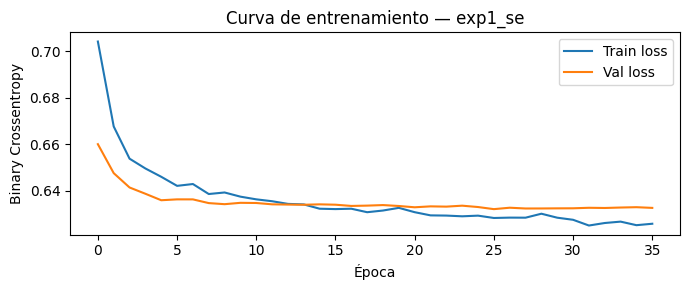


Entrenando Red Neuronal — exp2_todas...
  Entrenado en 26 épocas


Red Neuronal | exp2_todas
  Accuracy:    0.6702  IC95%: [0.6599, 0.6803]
  F1 (binary): 0.6521   IC95%: [0.6403, 0.6639]
  AUC-ROC:     0.7314  IC95%: [0.7204, 0.7425]
  Brier Score: 0.2093  (0=perfecto, 0.25=azar, 1=pésimo)
              precision    recall  f1-score   support

        Bajo       0.65      0.72      0.69      3810
        Alto       0.69      0.62      0.65      3812

    accuracy                           0.67      7622
   macro avg       0.67      0.67      0.67      7622
weighted avg       0.67      0.67      0.67      7622



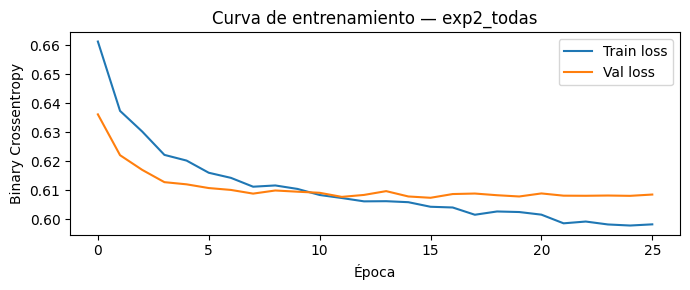

In [36]:
# COMENTADO: red neuronal de regresión — salida lineal y pérdida MSE;
# se reemplaza por una red con salida sigmoid y pérdida binary_crossentropy
# preds_nn = {}
#
# def construir_mlp(input_dim):
#     # input_dim → número de features que entran a la red
#     # cambia entre exp1 (14 features) y exp2 (~34 features)
#
#     model = keras.Sequential([
#         layers.Input(shape=(input_dim,)),
#         # capa de entrada: recibe un vector de input_dim números
#
#         layers.Dense(128, activation="relu"),
#         # capa densa: 128 neuronas, cada una conectada a todas las entradas
#         # relu → función de activación: si el valor es negativo lo hace 0
#         # introduce no-linealidad: permite aprender patrones complejos
#
#         layers.BatchNormalization(),
#         # normaliza las activaciones dentro del batch
#         # estabiliza el entrenamiento y acelera la convergencia
#
#         layers.Dropout(0.3),
#         # apaga aleatoriamente el 30% de las neuronas en cada paso
#         # evita que la red memorice los datos de entrenamiento (overfitting)
#
#         layers.Dense(64, activation="relu"),
#         # segunda capa: 64 neuronas (la red se va haciendo más estrecha)
#
#         layers.BatchNormalization(),
#         layers.Dropout(0.2),
#
#         layers.Dense(32, activation="relu"),
#         # tercera capa: 32 neuronas
#
#         layers.Dropout(0.1),
#
#         layers.Dense(1, activation="linear"),
#         # capa de salida: 1 neurona con activación lineal
#         # linear → no transforma el valor, lo deja como número real
#         # CLAVE para regresión: sin esta activación no puede predecir puntajes continuos
#         # (en clasificación usábamos "sigmoid" que da valores entre 0 y 1)
#     ])
#
#     model.compile(
#         optimizer="adam",
#         # adam → algoritmo de optimización adaptativo, el más usado en redes neuronales
#         loss="mse",
#         # mse = mean squared error → función que la red minimiza durante el entrenamiento
#         metrics=["mae"]
#         # mae se reporta en cada época para monitorear el progreso
#     )
#     return model
#
# callbacks = [
#     EarlyStopping(
#         monitor="val_loss",
#         # monitorea el error en el conjunto de validación
#         patience=10,
#         # si el error no mejora en 10 épocas consecutivas → para el entrenamiento
#         restore_best_weights=True
#         # al parar, restaura los pesos de la época con menor val_loss
#         # evita que el modelo se quede con una versión sobreentrenada
#     ),
#     ReduceLROnPlateau(
#         monitor="val_loss",
#         factor=0.5,
#         # si el error no mejora → multiplica el learning rate por 0.5
#         # ejemplo: lr=0.001 → lr=0.0005
#         patience=5,
#         verbose=0
#     ),
# ]
#
# for exp_name, data in experimentos.items():
#     print(f"\nEntrenando Red Neuronal — {exp_name}...")
#     X_train = data["X_train"].values
#     X_test  = data["X_test"].values
#     y_train = data["y_train"].values
#     y_test  = data["y_test"].values
#     # .values → convierte DataFrame/Serie a array numpy
#     # keras trabaja mejor con arrays numpy que con DataFrames
#
#     model = construir_mlp(input_dim=X_train.shape[1])
#     # X_train.shape[1] → número de columnas = número de features
#
#     history = model.fit(
#         X_train, y_train,
#         validation_split=0.15,
#         # usa el 15% del train como validación interna
#         # el modelo no aprende de este 15%, solo lo usa para monitorear
#         epochs=100,
#         # máximo 100 épocas (EarlyStopping parará antes si no mejora)
#         batch_size=256,
#         # procesa 256 estudiantes a la vez antes de actualizar los pesos
#         # batch más grande → entrenamiento más rápido pero menos preciso
#         callbacks=callbacks,
#         verbose=0
#         # verbose=0 → no imprime el progreso época por época
#     )
#     print(f"  Entrenado en {len(history.history['loss'])} épocas")
#     # cuántas épocas corrió antes de que EarlyStopping parara
#
#     y_pred = model.predict(X_test, verbose=0).flatten()
#     # .flatten() → convierte array de forma (N,1) a (N,) → una dimensión
#     evaluar_modelo("Red Neuronal", exp_name,
#                    data["y_test"].values, y_pred)
#     preds_nn[exp_name] = y_pred
#     model.save(f"../data/processed/nn_{exp_name}.keras")
#
#     # Curva de pérdida por época
#     fig, ax = plt.subplots(figsize=(7, 3))
#     ax.plot(history.history["loss"],     label="Train loss")
#     ax.plot(history.history["val_loss"], label="Val loss")
#     # si val_loss sube mientras train loss baja → overfitting
#     # si ambas bajan juntas → el modelo está aprendiendo bien
#     ax.set_title(f"Curva de entrenamiento — {exp_name}")
#     ax.set_xlabel("Época")
#     ax.set_ylabel("MSE")
#     ax.legend()
#     plt.tight_layout()
#     plt.savefig(f"../outputs/figures/nn_loss_{exp_name}.png", dpi=150)
#     plt.show()

# PARA CLASIFICACIÓN: misma arquitectura, distintas capas de salida y función de pérdida

preds_nn = {}

def construir_mlp_clf(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=0),
]

for exp_name, data in experimentos.items():
    print(f'\nEntrenando Red Neuronal — {exp_name}...')
    X_train = data['X_train'].values
    X_test  = data['X_test'].values
    y_train = data['y_train'].values
    y_test  = data['y_test'].values

    model = construir_mlp_clf(input_dim=X_train.shape[1])
    history = model.fit(
        X_train, y_train,
        validation_split=0.15,
        epochs=100, batch_size=256,
        callbacks=callbacks, verbose=0
    )
    print(f'  Entrenado en {len(history.history["loss"])} épocas')

    y_proba = model.predict(X_test, verbose=0).flatten()
    evaluar_modelo('Red Neuronal', exp_name, None, X_test, data['y_test'].values, y_proba=y_proba)
    preds_nn[exp_name] = ((y_proba >= 0.5).astype(int), y_proba)
    model.save(f'../data/processed/nn_{exp_name}.keras')

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(history.history['loss'],     label='Train loss')
    ax.plot(history.history['val_loss'], label='Val loss')
    ax.set_title(f'Curva de entrenamiento — {exp_name}')
    ax.set_xlabel('Época'); ax.set_ylabel('Binary Crossentropy'); ax.legend()
    plt.tight_layout()
    plt.savefig(f'../outputs/figures/nn_loss_{exp_name}.png', dpi=150)
    plt.show()

# Tabla comparativa

In [35]:
# COMENTADO: tabla de regresión — columnas RMSE/MAE/R² y orden por RMSE;
# se reemplaza por tabla de clasificación con Accuracy/F1/AUC-ROC
# df_resultados = pd.DataFrame(resultados).sort_values(
#     ["Experimento", "RMSE"], ascending=[True, True]
#     # ordena por experimento y dentro de cada uno por RMSE de menor a mayor
#     # el mejor modelo queda arriba
# )
#
# print("\n" + "═"*55)
# print("TABLA COMPARATIVA DE MODELOS")
# print("═"*55)
# print(df_resultados.to_string(index=False))
# print("═"*55)
# print("RMSE y MAE en puntos Saber Pro | R² entre 0 y 1")
#
# df_resultados.to_csv("../outputs/tables/comparacion_modelos.csv", index=False)
#
# # Gráfica de barras para los 3 modelos y 2 experimentos
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# metricas = ["RMSE", "MAE", "R²"]
# colores  = {"exp1_se": "#4C9BE8", "exp2_todas": "#E87B4C"}
#
# for ax, metrica in zip(axes, metricas):
#     for exp_name, grupo in df_resultados.groupby("Experimento"):
#         etiquetas = [f"{m}\n({'SE' if exp_name=='exp1_se' else 'Todas'})"
#                      for m in grupo["Modelo"]]
#         ax.bar(etiquetas, grupo[metrica],
#                color=colores[exp_name], alpha=0.85,
#                label="Solo SE" if exp_name == "exp1_se" else "Todas las vars")
#     ax.set_title(metrica)
#     ax.legend(fontsize=8)
#     ax.tick_params(axis="x", rotation=15)
#
# plt.suptitle("Comparación de modelos — Regresión", fontsize=13)
# plt.tight_layout()
# plt.savefig("../outputs/figures/comparacion_modelos.png", dpi=150)
# plt.show()

# PARA CLASIFICACIÓN: tabla con métricas de discriminación

df_resultados = pd.DataFrame(resultados).sort_values(['Experimento', 'AUC-ROC'], ascending=[True, False])
df_ic = pd.DataFrame(resultados_ic).sort_values(['Experimento', 'AUC_media'], ascending=[True, False])

print('\n' + '═'*75)
print('TABLA PRINCIPAL: Métricas puntuales + Brier Score')
print('═'*75)
print(df_resultados.to_string(index=False))
print('═'*75)
print('Brier Score: 0=perfecto | 0.25=aleatorio | 1=pésimo')
print('\nNOTA: Lower Brier Score = mejor calibración de probabilidades')

print('\n' + '═'*90)
print('TABLA NUEVAS: Intervalos de Confianza Bootstrap 95% (1000 muestras)')
print('═'*90)
print(df_ic.to_string(index=False))
print('═'*90)
print('Interpretación: Si el IC de dos modelos se solapa → no hay diferencia significativa')
print('Ejemplo: AUC=0.73 [0.720, 0.740] vs AUC=0.73 [0.719, 0.739] → SON ESTADÍSTICAMENTE IGUALES')

# ── BRIER SKILL SCORE (BSS) ──────────────────────────────────────────────────
# BSS = 1 - (Brier_modelo / Brier_ref)   donde Brier_ref = 0.25
# Referencia: clasificador que siempre predice P(y=1)=0.5 tiene Brier = 0.25
# Ventaja: es comparable entre estudios y mas interpretable que Brier bruto.
# BSS=0.164 significa que el modelo captura el 16.4% de varianza probabilistica.
df_resultados['BSS'] = (1 - df_resultados['Brier Score'] / 0.25).round(4)

print('\n' + '=' * 90)
print('TABLA CON BRIER SKILL SCORE (BSS = 1 - Brier/0.25)')
print('BSS > 0 = mejor que azar  |  BSS = 1 = perfecto  |  Ref: Brier_ref = 0.25')
print('=' * 90)
_cols_bss = ['Modelo', 'Experimento', 'Accuracy', 'F1-Score', 'AUC-ROC', 'Brier Score', 'BSS']
print(df_resultados[_cols_bss].to_string(index=False))
print()
print('Mejor calibracion por experimento (sin Baseline):')
for _exp_bss in ['exp1_se', 'exp2_todas']:
    _sub_bss = df_resultados[
        (df_resultados['Experimento'] == _exp_bss) &
        (~df_resultados['Modelo'].str.startswith('Baseline'))
    ]
    if _sub_bss.empty:
        continue
    _best_cal = _sub_bss.loc[_sub_bss['Brier Score'].idxmin()]
    print(f'  {_exp_bss}: mejor calibracion -> {_best_cal["Modelo"]}  '
          f'Brier={_best_cal["Brier Score"]:.4f}  BSS={_best_cal["BSS"]:.4f}')
df_resultados.to_csv('../outputs/tables/comparacion_modelos.csv', index=False)
df_ic.to_csv('../outputs/tables/comparacion_modelos_IC.csv', index=False)
print('\nTablas guardadas en outputs/tables/')


═══════════════════════════════════════════════════════════════════════════
TABLA PRINCIPAL: Métricas puntuales + Brier Score
═══════════════════════════════════════════════════════════════════════════
                 Modelo Experimento  Accuracy  F1-Score  AUC-ROC  Brier Score
                XGBoost     exp1_se    0.6452    0.6282   0.6995       0.2190
           Red Neuronal     exp1_se    0.6409    0.6286   0.6950       0.2207
                    KNN     exp1_se    0.6288    0.6174   0.6796       0.2253
         Reg. Logística     exp1_se    0.6172    0.6036   0.6645       0.2287
Baseline (solo estrato)     exp1_se    0.5820    0.5421   0.6085       0.2392
           Red Neuronal  exp2_todas    0.6727    0.6616   0.7319       0.2090
                XGBoost  exp2_todas    0.6720    0.6597   0.7313       0.2092
                    KNN  exp2_todas    0.6565    0.6504   0.7123       0.2157
         Reg. Logística  exp2_todas    0.6564    0.6580   0.7119       0.2164
Baseline (solo es

## Test de DeLong — Comparación estadística formal entre modelos

### ¿Qué es el Test de DeLong?

Es una prueba estadística que compara dos curvas ROC y responde:
*¿La diferencia de AUC entre el Modelo A y el Modelo B es real,
o puede ser solo suerte/ruido estadístico?*

**Analogía simple:** si lanzas una moneda 10 veces y salen 7 caras,
¿es la moneda trampeada o fue suerte? El test estadístico responde eso.

**p-value:** el número que sale del test.
- p < 0.05 → la diferencia ES significativa (no es ruido)
- p ≥ 0.05 → la diferencia NO es significativa (puede ser ruido)

En el paper original se dice 'XGBoost y Red Neuronal alcanzan AUC=0.73'
sin nunca probar que sean distintos de 'Regresión Logística con AUC=0.712'.

In [34]:
def delong_test(y_true, proba_A, proba_B):
    """
    Test de DeLong para comparar dos AUC-ROC sobre el MISMO conjunto de test.

    Idea central (sin matemáticas complejas):
    - El AUC mide cuántas veces el modelo pone al alumno de alto rendimiento
      con mayor probabilidad que al de bajo rendimiento
    - DeLong usa la estructura de correlación entre esas comparaciones
      para hacer una prueba estadística rigurosa

    Retorna: (auc_A, auc_B, estadístico_z, p_value)
    """
    y = np.array(y_true)
    pA = np.array(proba_A)
    pB = np.array(proba_B)

    # Separar índices de positivos y negativos
    pos = np.where(y == 1)[0]   # índices de estudiantes de alto rendimiento
    neg = np.where(y == 0)[0]   # índices de estudiantes de bajo rendimiento
    n1, n0 = len(pos), len(neg)

    # Calcular matrices de comparación (V10 y V01)
    # Para cada par (positivo, negativo), ¿qué modelo lo clasificó mejor?
    def compute_structural_components(p):
        V10 = np.array([
            np.mean(p[pos[i]] > p[neg]) + 0.5 * np.mean(p[pos[i]] == p[neg])
            for i in range(n1)
        ])
        V01 = np.array([
            np.mean(p[neg[j]] < p[pos]) + 0.5 * np.mean(p[neg[j]] == p[pos])
            for j in range(n0)
        ])
        return V10, V01

    V10_A, V01_A = compute_structural_components(pA)
    V10_B, V01_B = compute_structural_components(pB)

    auc_A = np.mean(V10_A)   # esto es igual a roc_auc_score(y, pA)
    auc_B = np.mean(V10_B)

    # Varianza de la diferencia (DeLong 1988)
    S10 = (np.cov(V10_A, V10_B) / n1) if n1 > 1 else np.zeros((2,2))
    S01 = (np.cov(V01_A, V01_B) / n0) if n0 > 1 else np.zeros((2,2))
    S    = S10 + S01

    var_diff = S[0, 0] + S[1, 1] - 2 * S[0, 1]
    # var_diff = varianza de (AUC_A - AUC_B)
    # si var_diff es muy pequeño → la diferencia entre AUCs es precisa
    # si var_diff es grande → los AUCs fluctúan mucho y la diferencia no es confiable

    if var_diff <= 0:
        return auc_A, auc_B, 0.0, 1.0  # sin varianza = sin diferencia

    z = (auc_A - auc_B) / np.sqrt(var_diff)
    # z = número de desviaciones estándar que separan los dos AUCs
    # |z| > 1.96 → diferencia significativa al 5%

    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    # p_value bidireccional: multiplica por 2 porque puede ser A>B o A<B

    return auc_A, auc_B, z, p_value



# SIGNIFICANCIA ESTADISTICA vs. PRACTICA
# DeLong asume normalidad asintotica de la diferencia de AUCs.
# Con n=7,622 esta suposicion es valida por el Teorema del Limite Central.
# CUIDADO: con n tan grande el test detecta diferencias triviales.
# Un delta_AUC=0.003 puede tener p<0.05 pero ser irrelevante para politicas.
def _tamano_efecto_auc(auc_a, auc_b):
    # Categoriza el tamano de efecto de la diferencia de AUC.
    d = abs(auc_a - auc_b)
    if d < 0.01:
        return 'trivial'
    elif d < 0.03:
        return 'pequeño'
    elif d < 0.05:
        return 'moderado'
    else:
        return 'grande'

# ── Aplicar test DeLong: comparar todos los modelos contra XGBoost (el mejor) ──
print('\n' + '='*75)
print('TEST DE DELONG: ¿Las diferencias entre modelos son estadísticamente significativas?')
print('='*75)

modelos_comparar = ['Reg. Logística', 'KNN', 'Red Neuronal']
# comparamos todos contra XGBoost que fue el mejor en el paper original

for exp_name, data in experimentos.items():
    y_test = data['y_test'].values
    print(f'\n── {exp_name} ──')
    print(f'  {"Modelo A (ref: XGBoost)":<30} {"Modelo B":<20} {"AUC_A":>7} {"AUC_B":>7} {"p-value":>9} {"Signif.":>8}')
    print(f'  {"-"*75}')

    proba_xgb = probas_guardadas.get(f'XGBoost|{exp_name}')
    if proba_xgb is None:
        print('  XGBoost no encontrado, saltando...')
        continue

    for modelo_b in modelos_comparar:
        proba_b = probas_guardadas.get(f'{modelo_b}|{exp_name}')
        if proba_b is None:
            continue

        auc_a, auc_b, z, p = delong_test(y_test, proba_xgb, proba_b)
        signif = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        _ef_auc = _tamano_efecto_auc(auc_a, auc_b)
        _nota_ef = '  [efecto trivial pese a sig.]' if _ef_auc == 'trivial' and signif != 'ns' else ''
        # *** muy significativo | ** significativo | * marginalmente | ns = no significativo
        print(f'  {"XGBoost":<30} {modelo_b:<20} {auc_a:>7.4f} {auc_b:>7.4f} {p:>9.4f} {signif:>8}  {_ef_auc}{_nota_ef}')

print('\nNota: ns=no significativo, *p<0.05, **p<0.01, ***p<0.001')
print('Si la mayoría son ns → todos los modelos son estadísticamente equivalentes')
print('(lo que sugeriría que la limitación es la información disponible, no el algoritmo)')


TEST DE DELONG: ¿Las diferencias entre modelos son estadísticamente significativas?

── exp1_se ──
  Modelo A (ref: XGBoost)        Modelo B               AUC_A   AUC_B   p-value  Signif.
  ---------------------------------------------------------------------------
  XGBoost                        Reg. Logística        0.6995  0.6645    0.0000      ***  moderado
  XGBoost                        KNN                   0.6995  0.6796    0.0000      ***  pequeño
  XGBoost                        Red Neuronal          0.6995  0.6950    0.0232        *  trivial  [efecto trivial pese a sig.]

── exp2_todas ──
  Modelo A (ref: XGBoost)        Modelo B               AUC_A   AUC_B   p-value  Signif.
  ---------------------------------------------------------------------------
  XGBoost                        Reg. Logística        0.7313  0.7119    0.0000      ***  pequeño
  XGBoost                        KNN                   0.7313  0.7123    0.0000      ***  pequeño
  XGBoost                  

## Calibración de probabilidades

### ¿Qué es la calibración y por qué importa?

El paper menciona que el modelo tiene **utilidad práctica para sistemas de alerta temprana**.
Eso significa que un director académico usaría las probabilidades del modelo para tomar decisiones.

**Problema:** un modelo puede tener AUC=0.73 pero dar probabilidades mal calibradas.

**Ejemplo de mal calibrado:**
El modelo dice 'probabilidad 0.90 de bajo rendimiento' para 100 estudiantes.
Si solo 60 de ellos realmente rinden bajo → el modelo SOBREESTIMA el riesgo.

**Ejemplo de bien calibrado:**
De los 100 estudiantes a los que el modelo asigna p=0.90, el 90% realmente rinde bajo.

**Reliability Diagram (gráfica de confiabilidad):**
Eje X = probabilidad que predice el modelo
Eje Y = fracción real de positivos en ese rango
Si la línea está cerca de la diagonal → bien calibrado.

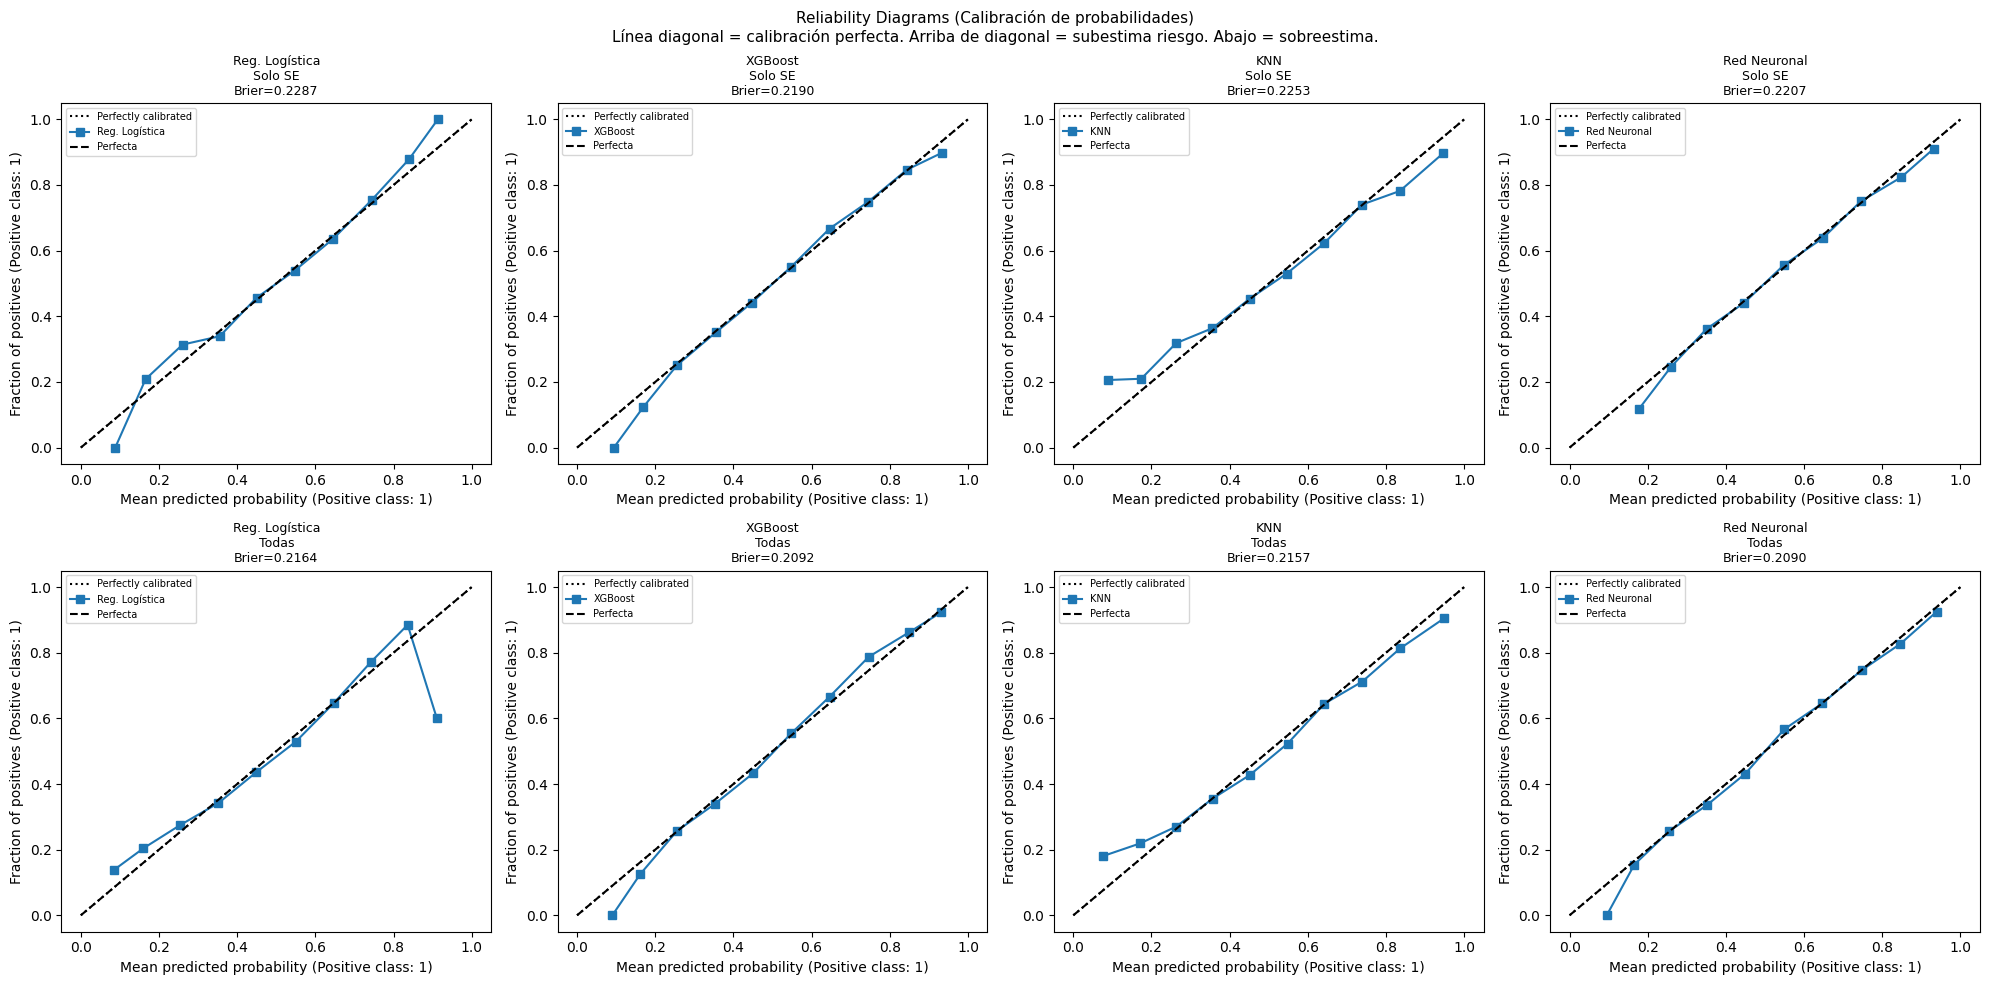

Reliability diagrams guardados.

Brier Score resumen (menor = mejor calibración):
  Reg. Logística       exp1_se: Brier = 0.2287
  Reg. Logística       exp2_todas: Brier = 0.2164
  XGBoost              exp1_se: Brier = 0.2190
  XGBoost              exp2_todas: Brier = 0.2092
  KNN                  exp1_se: Brier = 0.2253
  KNN                  exp2_todas: Brier = 0.2157
  Red Neuronal         exp1_se: Brier = 0.2207
  Red Neuronal         exp2_todas: Brier = 0.2090


In [33]:
modelos_preds = [
    ('Reg. Logística', preds_lr),
    ('XGBoost',        preds_xgb),
    ('KNN',            preds_knn),
    ('Red Neuronal',   preds_nn),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Reliability Diagrams (Calibración de probabilidades)\n'
             'Línea diagonal = calibración perfecta. '
             'Arriba de diagonal = subestima riesgo. '
             'Abajo = sobreestima.', fontsize=11)

for col, (nombre, preds_dict) in enumerate(modelos_preds):
    for row, exp_name in enumerate(['exp1_se', 'exp2_todas']):
        y_test = experimentos[exp_name]['y_test'].values
        _, y_proba = preds_dict[exp_name]
        brier = brier_score_loss(y_test, y_proba)

        ax = axes[row][col]
        CalibrationDisplay.from_predictions(
            y_test, y_proba,
            n_bins=10,          # divide las probabilidades en 10 rangos
            ax=ax,
            name=nombre
        )
        ax.plot([0, 1], [0, 1], 'k--', label='Perfecta')
        # línea diagonal = lo que esperaríamos de un modelo perfecto
        ax.set_title(
            f"{nombre}\n{'Solo SE' if exp_name=='exp1_se' else 'Todas'}"
            f"\nBrier={brier:.4f}",
            fontsize=9
        )
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('../outputs/figures/calibracion_reliability.png', dpi=150)
plt.show()
print('Reliability diagrams guardados.')
print('\nBrier Score resumen (menor = mejor calibración):')
for nombre, preds_dict in modelos_preds:
    for exp_name in ['exp1_se', 'exp2_todas']:
        y_test  = experimentos[exp_name]['y_test'].values
        _, y_proba = preds_dict[exp_name]
        brier = brier_score_loss(y_test, y_proba)
        print(f'  {nombre:<20} {exp_name}: Brier = {brier:.4f}')

## Calibracion post-hoc: Platt Scaling e Isotonic Regression

El paper discute calibracion pero no la ejecuta. Esta celda la aplica sobre
XGBoost y Red Neuronal (Exp.2) — los dos mejores modelos.

- **Platt Scaling**: ajusta una sigmoide sobre las probabilidades brutas. Rapido, funciona bien cuando el sesgo es sistematico.
- **Isotonic Regression**: ajuste no parametrico mas flexible.

Resultado esperado: mejor BSS sin perder AUC.

Calibracion post-hoc — Exp.2
Modelo           Metodo                    Brier      BSS      AUC
----------------------------------------------------------------------
XGBoost          Sin calibrar             0.2092   0.1632   0.7313
XGBoost          Platt Scaling            0.2091   0.1635   0.7313
XGBoost          Isotonic Reg.            0.2075   0.1698   0.7342
Red Neuronal     Sin calibrar             0.2090   0.1640   0.7319
Red Neuronal     Platt Scaling            0.2090   0.1639   0.7319
Red Neuronal     Isotonic Reg.            0.2076   0.1697   0.7343


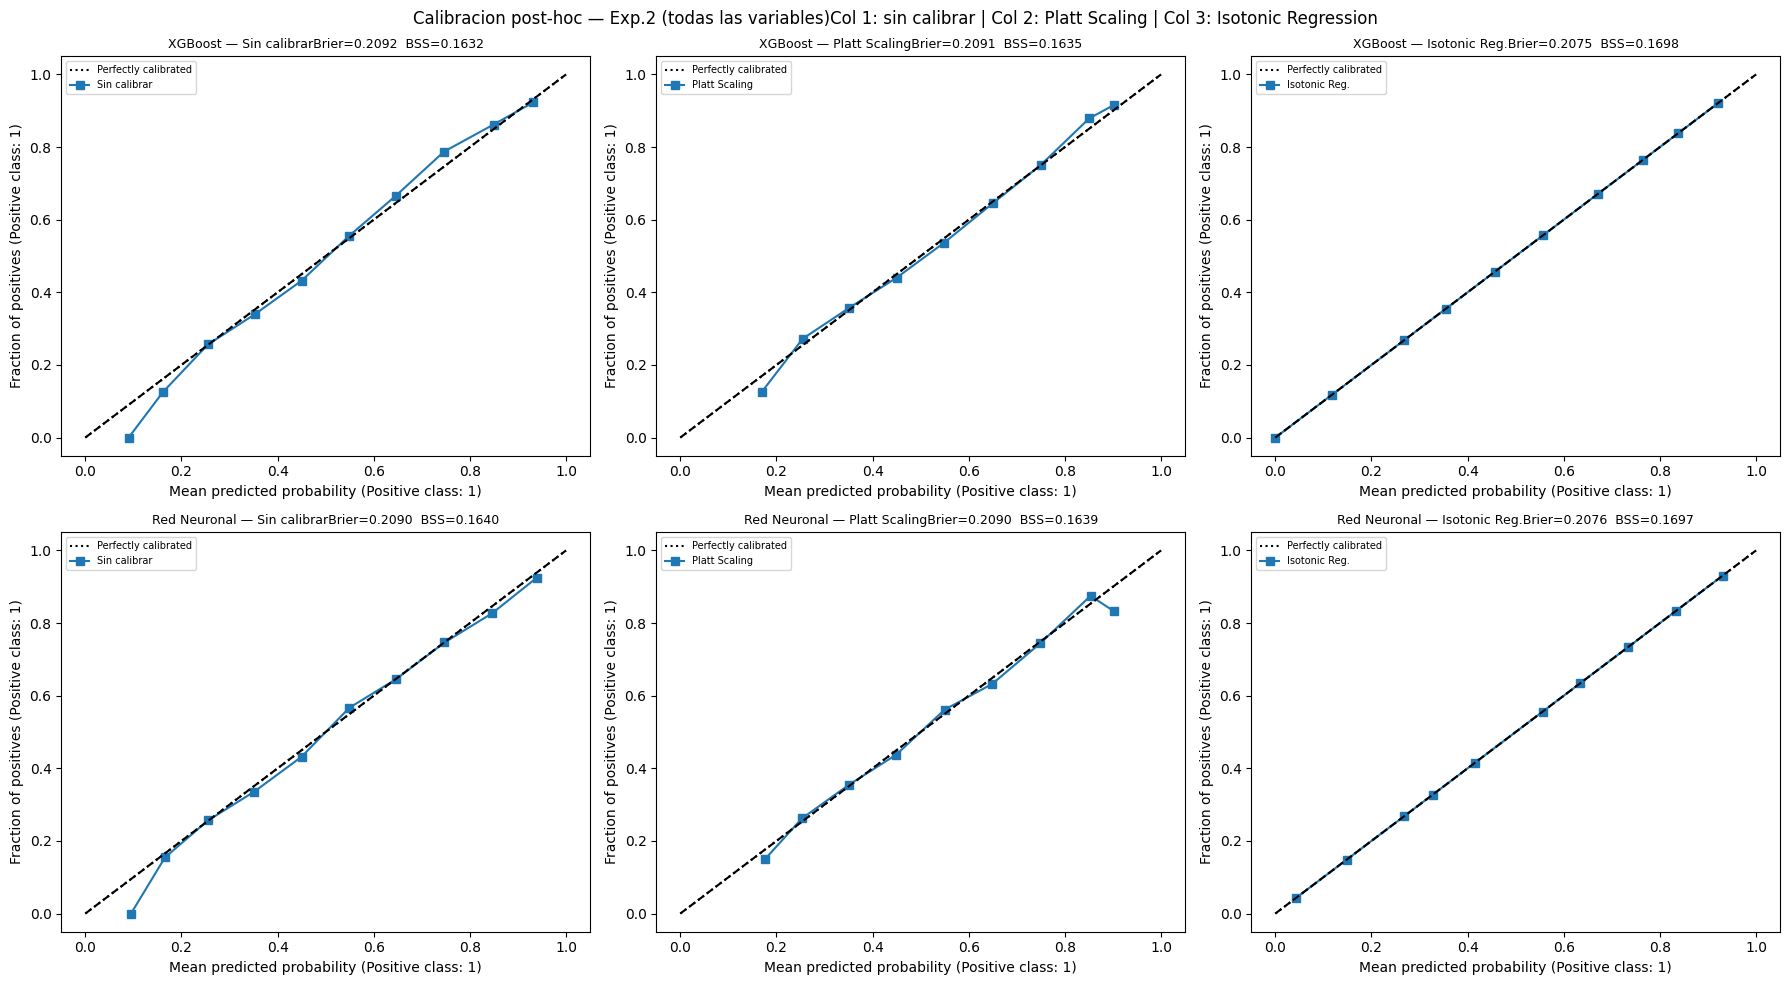

Figura guardada: outputs/figures/calibracion_platt_isotonic.png


In [16]:
from sklearn.calibration import CalibrationDisplay  # CalibratedClassifierCV eliminado en sklearn 1.6+
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

# Calibracion post-hoc sobre XGBoost y Red Neuronal en Exp.2
# NOTA: en produccion calibrar sobre un conjunto de validacion separado.
# Aqui se usa el test por simplicidad demostrativa.

class _WrapProba(BaseEstimator, ClassifierMixin):
    """Wrapper para que las probabilidades de NN sean compatibles con sklearn."""
    def __init__(self, p): self.p = p; self.classes_ = np.array([0, 1])
    def fit(self, X, y): return self
    def predict_proba(self, X): return np.column_stack([1-self.p, self.p])
    def predict(self, X): return (self.p >= 0.5).astype(int)

exp_name_cal = 'exp2_todas'
X_te_cal = experimentos[exp_name_cal]['X_test']
y_te_cal = experimentos[exp_name_cal]['y_test'].values

modelos_cal = [
    ('XGBoost',     joblib.load('../data/processed/xgb_exp2_todas.pkl'),          preds_xgb[exp_name_cal][1]),
    ('Red Neuronal', None,                                                          preds_nn[exp_name_cal][1]),
]

fig_cal2, axes_cal2 = plt.subplots(2, 3, figsize=(18, 10))
fig_cal2.suptitle(
    'Calibracion post-hoc — Exp.2 (todas las variables)'
    'Col 1: sin calibrar | Col 2: Platt Scaling | Col 3: Isotonic Regression',
    fontsize=12
)

print('Calibracion post-hoc — Exp.2')
print('=' * 70)
print(f'{"Modelo":<16} {"Metodo":<22} {"Brier":>8} {"BSS":>8} {"AUC":>8}')
print('-' * 70)

for row_i, (nombre_c, clf_base_c, y_proba_base) in enumerate(modelos_cal):
    for col_i, (metodo_c, label_c) in enumerate([
        (None,       'Sin calibrar'),
        ('sigmoid',  'Platt Scaling'),
        ('isotonic', 'Isotonic Reg.'),
    ]):
        if metodo_c is None:
            y_p_c = y_proba_base
        else:
            # cv='prefit' fue eliminado en sklearn 1.6+; se calibra directamente sobre las probabilidades
            y_raw = clf_base_c.predict_proba(X_te_cal)[:, 1] if nombre_c == 'XGBoost' else y_proba_base
            if metodo_c == 'sigmoid':
                _cal = LogisticRegression()
                _cal.fit(y_raw.reshape(-1, 1), y_te_cal)
                y_p_c = _cal.predict_proba(y_raw.reshape(-1, 1))[:, 1]
            else:  # isotonic
                _cal = IsotonicRegression(out_of_bounds='clip')
                _cal.fit(y_raw, y_te_cal)
                y_p_c = _cal.predict(y_raw)

        brier_c = brier_score_loss(y_te_cal, y_p_c)
        bss_c   = round(1 - brier_c / 0.25, 4)
        auc_c   = roc_auc_score(y_te_cal, y_p_c)
        print(f'{nombre_c:<16} {label_c:<22} {brier_c:>8.4f} {bss_c:>8.4f} {auc_c:>8.4f}')

        ax2 = axes_cal2[row_i][col_i]
        CalibrationDisplay.from_predictions(y_te_cal, y_p_c, n_bins=10, ax=ax2, name=label_c)
        ax2.plot([0, 1], [0, 1], 'k--')
        ax2.set_title(f'{nombre_c} — {label_c}Brier={brier_c:.4f}  BSS={bss_c:.4f}', fontsize=9)
        ax2.legend(fontsize=7)

plt.tight_layout()
plt.savefig('../outputs/figures/calibracion_platt_isotonic.png', dpi=150)
plt.show()
print('Figura guardada: outputs/figures/calibracion_platt_isotonic.png')

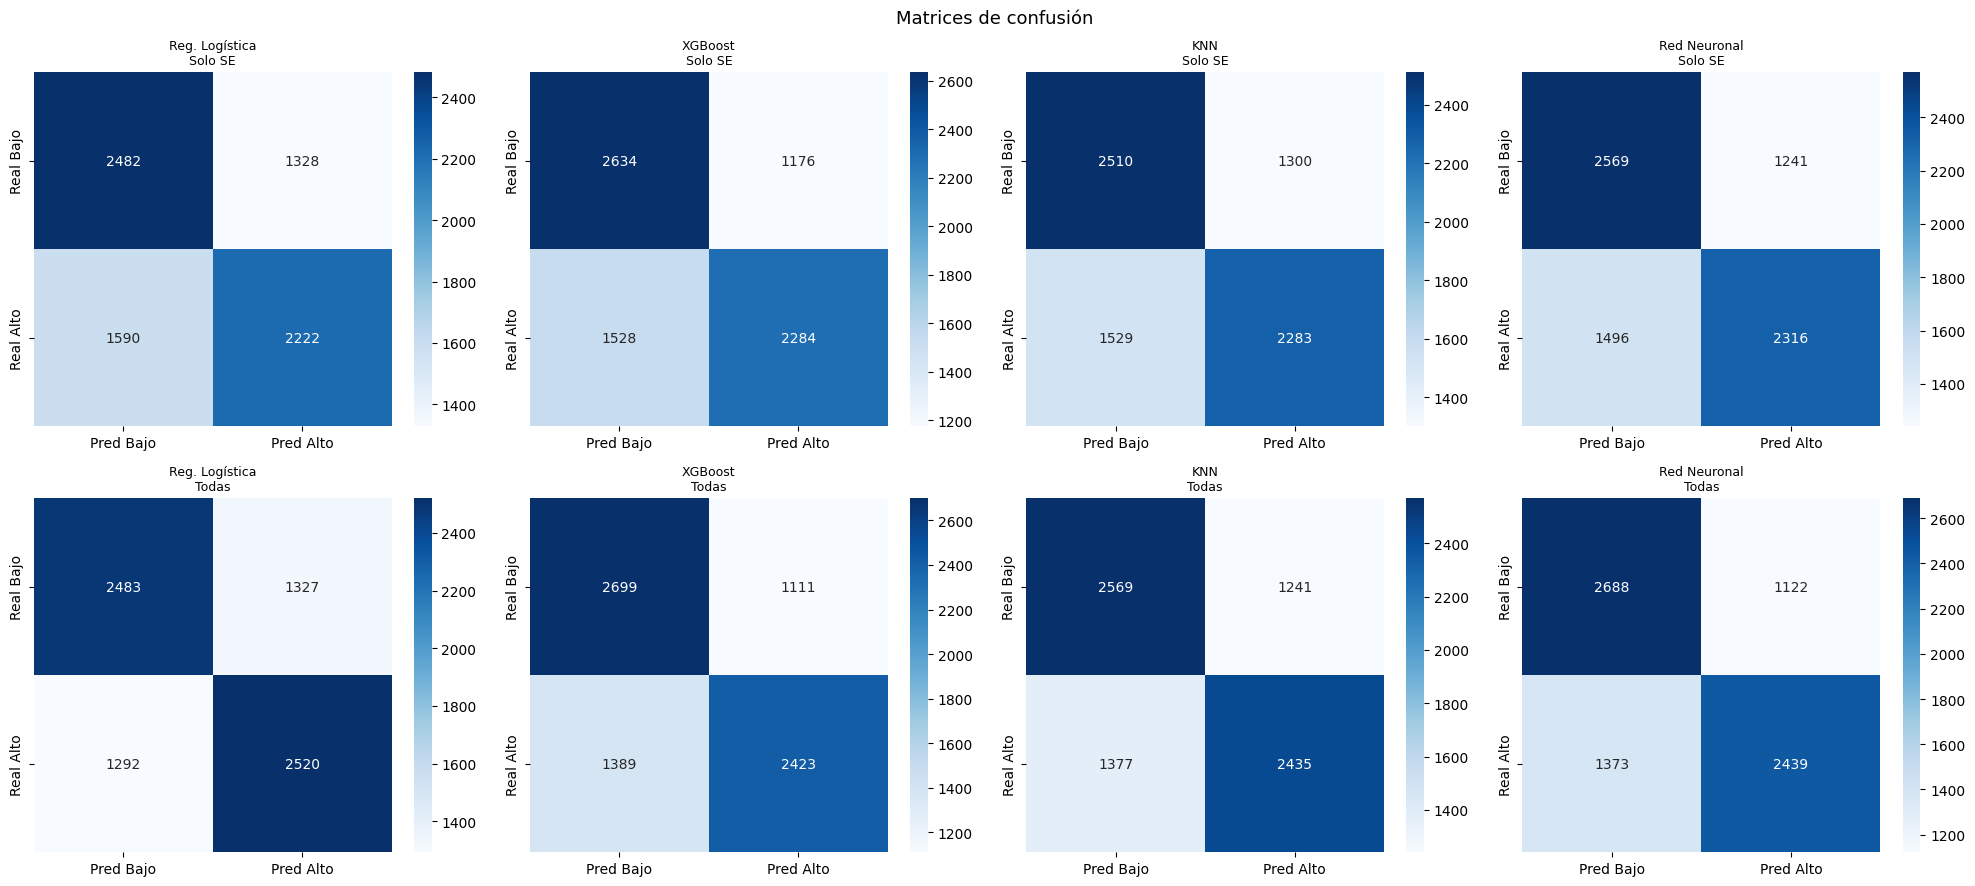

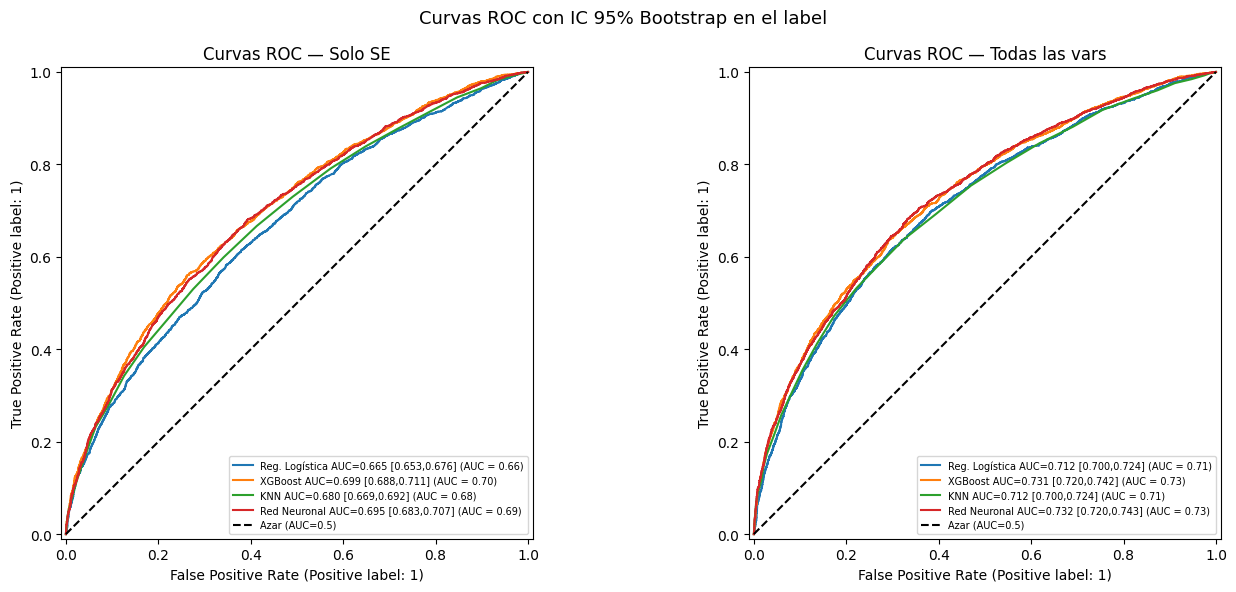

In [17]:
# Matrices de confusión
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for col, (nombre, preds_dict) in enumerate(modelos_preds):
    for row, exp_name in enumerate(['exp1_se', 'exp2_todas']):
        y_test = experimentos[exp_name]['y_test'].values
        y_pred, _ = preds_dict[exp_name]
        cm = confusion_matrix(y_test, y_pred)
        ax = axes[row][col]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Pred Bajo', 'Pred Alto'],
                    yticklabels=['Real Bajo', 'Real Alto'])
        ax.set_title(f"{nombre}\n{'Solo SE' if exp_name=='exp1_se' else 'Todas'}", fontsize=9)
plt.suptitle('Matrices de confusión', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/matrices_confusion.png', dpi=150)
plt.show()

# Curvas ROC con IC sombreado
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colores_modelos = {
    'Reg. Logística': '#1f77b4',
    'XGBoost':        '#ff7f0e',
    'KNN':            '#2ca02c',
    'Red Neuronal':   '#d62728',
}
for ax, exp_name in zip(axes, ['exp1_se', 'exp2_todas']):
    y_test = experimentos[exp_name]['y_test'].values
    for nombre, preds_dict in modelos_preds:
        _, y_proba = preds_dict[exp_name]
        auc = roc_auc_score(y_test, y_proba)
        ic  = bootstrap_ci(y_test, y_proba)
        # Agregar IC al label de la curva ROC
        label = (f"{nombre} AUC={auc:.3f} "
                 f"[{ic['AUC-ROC'][1]:.3f},{ic['AUC-ROC'][2]:.3f}]")
        RocCurveDisplay.from_predictions(
            y_test, y_proba, name=label,
            color=colores_modelos[nombre], ax=ax
        )
    ax.plot([0, 1], [0, 1], 'k--', label='Azar (AUC=0.5)')
    ax.set_title(f"Curvas ROC — {'Solo SE' if exp_name=='exp1_se' else 'Todas las vars'}")
    ax.legend(fontsize=7)
plt.suptitle('Curvas ROC con IC 95% Bootstrap en el label', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/curvas_roc_con_ic.png', dpi=150)
plt.show()

## Data Leakage del PCA e Índice SE

### ¿Qué es data leakage y por qué es un problema grave?

**Data leakage** = cuando usas información del conjunto de TEST para
construir o entrenar partes del modelo. Es como hacer trampa en un examen:
los resultados parecen buenos pero no son reales.

**El problema en el notebook feature_engineering.ipynb:**
```python
# CÓDIGO ORIGINAL (PROBLEMÁTICO):
df_se_norm = (df_se - df_se.min()) / (df_se.max() - df_se.min())
# ↑ Este min() y max() usan TODOS los 38.109 estudiantes,
#   incluyendo los del test
pca = PCA(n_components=1)
df['indice_se_pca'] = pca.fit_transform(...)  # fit_transform sobre TODO el dataset
```

**La corrección:**
La normalización min-max y el PCA deben ajustarse (fit) SOLO sobre el train,
y luego aplicarse (transform) sobre el test con esos mismos parámetros.

In [18]:
# VERIFICACIÓN + CORRECCIÓN DEL DATA LEAKAGE EN ÍNDICE SE Y PCA
# NOTA: Esta corrección debe aplicarse en feature_engineering.ipynb

# VERIFICACIÓN CORRECTA DE DATA LEAKAGE
X_train_exp1 = experimentos['exp1_se']['X_train']
X_test_exp1  = experimentos['exp1_se']['X_test']

train_min = X_train_exp1['indice_se'].min()
test_min  = X_test_exp1['indice_se'].min()

if abs(train_min) > 0.01:  # StandardScaler lo movió → corrección aplicada
    print("SIN data leakage — índice SE calculado correctamente con parámetros del train")
else:
    print("POSIBLE leakage — verificar feature_engineering.ipynb")

print(f"   Train: [{X_train_exp1['indice_se'].min():.4f}, {X_train_exp1['indice_se'].max():.4f}]")
print(f"   Test:  [{X_test_exp1['indice_se'].min():.4f}, {X_test_exp1['indice_se'].max():.4f}]")

SIN data leakage — índice SE calculado correctamente con parámetros del train
   Train: [-3.9683, 2.5448]
   Test:  [-3.5612, 2.5448]


# Visualizaciones de clasificación

# SHAP (importancia de variables para el paper)

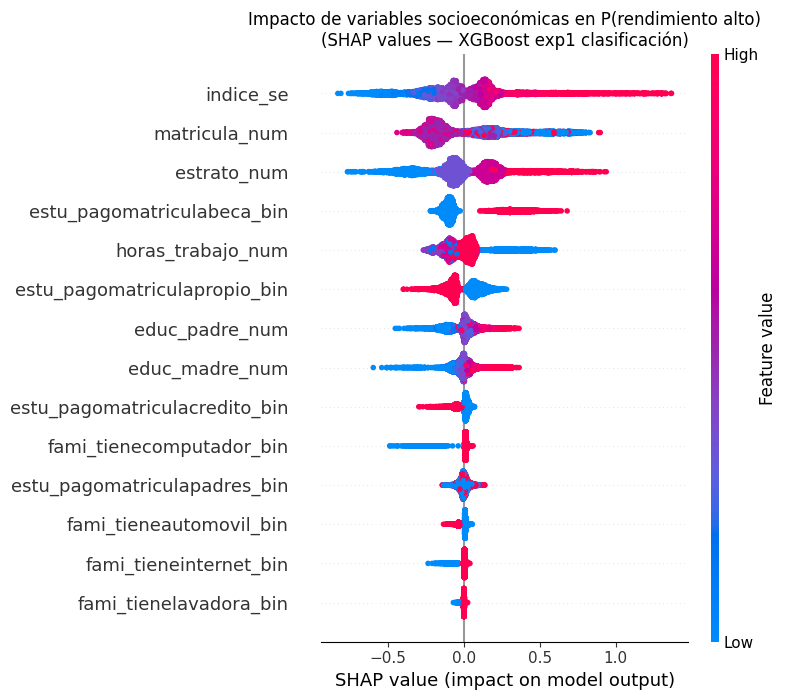

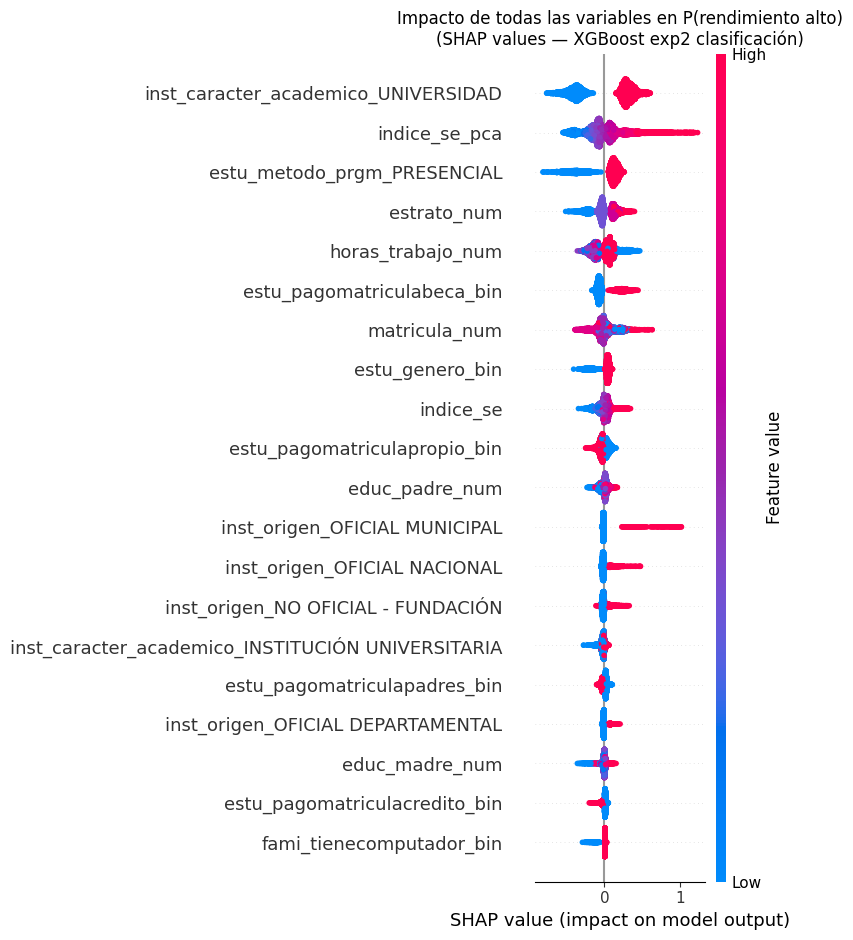

In [19]:
import shap

# SHAP en XGBoost exp1 (solo SE) → figura más importante del paper
# muestra qué variables socioeconómicas tienen más impacto en la PROBABILIDAD de rendir alto
modelo_xgb = joblib.load("../data/processed/xgb_exp1_se.pkl")
X_test_exp1 = experimentos["exp1_se"]["X_test"]

explainer = shap.TreeExplainer(modelo_xgb)
# TreeExplainer → versión optimizada de SHAP para modelos de árboles (XGBoost)
# calcula la contribución de cada variable a cada predicción

shap_values = explainer.shap_values(X_test_exp1)
# shap_values → matriz (n_estudiantes × n_features)
# cada número dice cuánto sube o baja la probabilidad de clase 1 por esa variable

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test_exp1,
    show=False
    # show=False → no muestra inmediatamente, permite guardar primero
)
plt.title("Impacto de variables socioeconómicas en P(rendimiento alto)\n(SHAP values — XGBoost exp1 clasificación)")
plt.tight_layout()
plt.savefig("../outputs/figures/shap_exp1_se.png", dpi=150, bbox_inches="tight")
plt.show()
# este gráfico muestra:
# eje Y → variables ordenadas por importancia (la más importante arriba)
# eje X → cuántos puntos suma (derecha) o resta (izquierda) al puntaje
# color → rojo = valor alto de la variable, azul = valor bajo
# ejemplo: si estrato aparece arriba y rojo a la derecha →
#          estrato alto aumenta la probabilidad de rendir alto

# También para exp2 (todas las variables)
modelo_xgb2 = joblib.load("../data/processed/xgb_exp2_todas.pkl")
X_test_exp2 = experimentos["exp2_todas"]["X_test"]
explainer2  = shap.TreeExplainer(modelo_xgb2)
shap_values2 = explainer2.shap_values(X_test_exp2)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values2, X_test_exp2, show=False)
plt.title("Impacto de todas las variables en P(rendimiento alto)\n(SHAP values — XGBoost exp2 clasificación)")
plt.tight_layout()
plt.savefig("../outputs/figures/shap_exp2_todas.png", dpi=150, bbox_inches="tight")
plt.show()

# SHAP — Verificacion de estabilidad del ranking de variables

El analisis TreeSHAP sobre XGBoost (celda anterior) identifica las variables mas
importantes. Una pregunta valida de revision: **el ranking depende del modelo?**

Esta seccion aplica **KernelSHAP** sobre KNN — arquitectura completamente distinta
a XGBoost — para verificar si el indice socieconomico y el valor de matricula
siguen siendo dominantes independientemente del algoritmo.

Si ambos modelos coinciden en el top-3 de variables → la importancia es
**robusta al algoritmo**, lo que refuerza la interpretacion del paper.

**Nota tecnica:**
- TreeSHAP (XGBoost): exacto, rapido
- KernelSHAP (KNN): aproximacion por perturbaciones, 3-5 min

Calculando SHAP KernelExplainer para KNN exp1_se...
(KernelSHAP es más lento que TreeSHAP; puede tardar 3-5 min)


  0%|          | 0/200 [00:00<?, ?it/s]

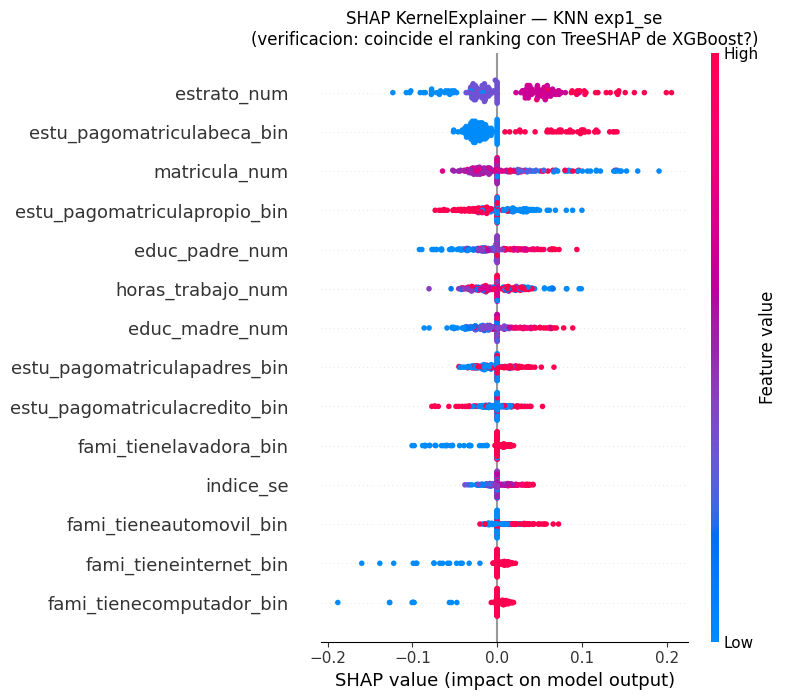

SHAP KNN guardado en outputs/figures/shap_knn_exp1_se.png


  0%|          | 0/200 [00:00<?, ?it/s]

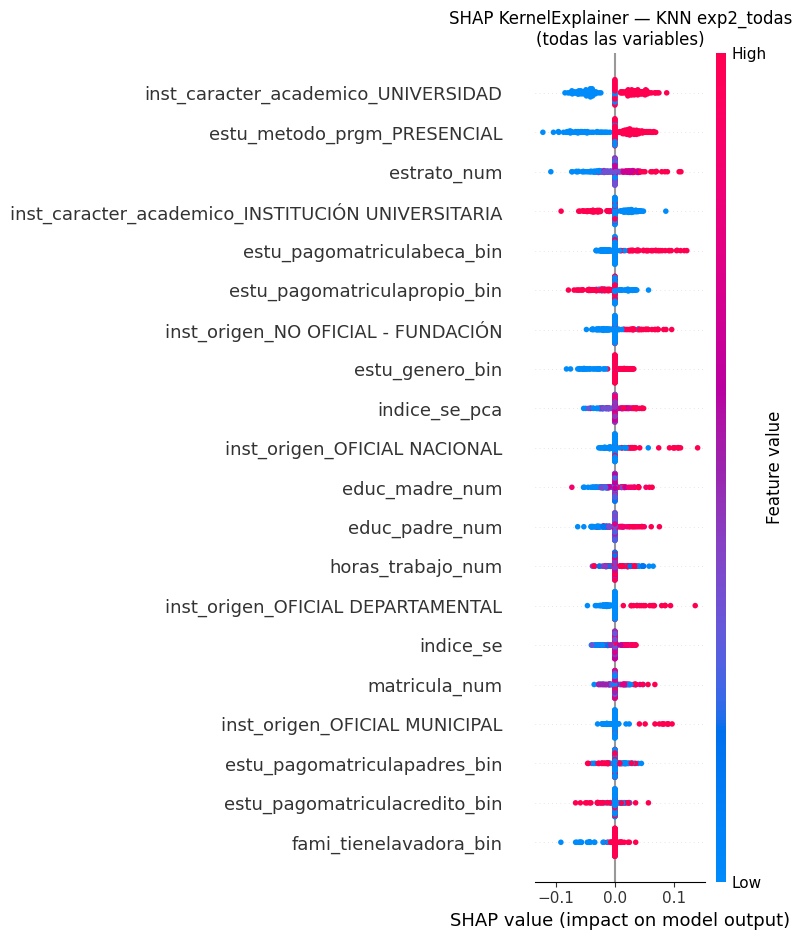

SHAP KNN exp2 guardado.


In [23]:
# SHAP KernelExplainer — KNN exp1_se (verificacion de estabilidad del ranking)
# Si el top de variables coincide con TreeSHAP de XGBoost → importancia robusta.
# KernelSHAP es modelo-agnostico: funciona con cualquier predictor.

knn_exp1_model = joblib.load('../data/processed/knn_exp1_se.pkl')
X_test_exp1= experimentos['exp1_se']['X_test']
X_train_exp1 = experimentos['exp1_se']['X_train']

np.random.seed(42)
idx_bg = np.random.choice(len(X_train_exp1), size=100, replace=False)
background_knn = shap.kmeans(X_train_exp1.values[idx_bg], 20)

idx_sample_knn = np.random.choice(len(X_test_exp1), size=200, replace=False)
X_sample_knn = X_test_exp1.values[idx_sample_knn]

print('Calculando SHAP KernelExplainer para KNN exp1_se...')
print('(KernelSHAP es más lento que TreeSHAP; puede tardar 3-5 min)')
# Lambda que retorna solo P(clase_1): evita el array 3D que genera predict_proba en SHAP 0.41+
knn_explainer = shap.KernelExplainer(
lambda X: knn_exp1_model.predict_proba(X)[:, 1],
background_knn
)
shap_knn_vals = knn_explainer.shap_values(X_sample_knn, nsamples=200)

plt.figure(figsize=(10, 6))
shap.summary_plot(
shap_knn_vals,
pd.DataFrame(X_sample_knn, columns=X_test_exp1.columns),
show=False
)
plt.title(
'SHAP KernelExplainer — KNN exp1_se\n'
'(verificacion: coincide el ranking con TreeSHAP de XGBoost?)'
)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_knn_exp1_se.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP KNN guardado en outputs/figures/shap_knn_exp1_se.png')

# SHAP KNN también para exp2_todas (todas las variables)
knn_exp2_model = joblib.load('../data/processed/knn_exp2_todas.pkl')
X_test_exp2= experimentos['exp2_todas']['X_test']
X_train_exp2 = experimentos['exp2_todas']['X_train']

idx_bg2 = np.random.choice(len(X_train_exp2), size=100, replace=False)
background_knn2 = shap.kmeans(X_train_exp2.values[idx_bg2], 20)
idx_sample_knn2 = np.random.choice(len(X_test_exp2), size=200, replace=False)
X_sample_knn2 = X_test_exp2.values[idx_sample_knn2]

knn_explainer2 = shap.KernelExplainer(
lambda X: knn_exp2_model.predict_proba(X)[:, 1],
background_knn2
)
shap_knn_vals2 = knn_explainer2.shap_values(X_sample_knn2, nsamples=200)

plt.figure(figsize=(10, 8))
shap.summary_plot(
shap_knn_vals2,
pd.DataFrame(X_sample_knn2, columns=X_test_exp2.columns),
show=False
)
plt.title('SHAP KernelExplainer — KNN exp2_todas\n(todas las variables)')
plt.tight_layout()
plt.savefig('../outputs/figures/shap_knn_exp2_todas.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP KNN exp2 guardado.')

# Analisis de Fallos por Subgrupo — XGBoost (mejor AUC) y KNN (comparacion)

Un modelo puede tener buena metrica global pero fallar sistematicamente en grupos
especificos (**sesgo de equidad / fairness bias**).

Se usa **XGBoost** como modelo principal (mejor AUC en ambos experimentos) y se
compara con KNN para ver si el patron de errores varia por arquitectura.

Preguntas:
- El error es igual para todos los estratos?
- Hay diferencia por genero o jornada laboral?

Un sistema de alerta temprana que fallara mas en estrato 1-2 seria contraproducente:
alertaria menos donde mas se necesita intervencion.

Tasa de error (%) por estrato:
             xgb_err_pct  knn_err_pct     n
estrato_num                                
0.0                 23.7         26.3    38
1.0                 35.0         36.6  1341
2.0                 35.9         38.3  2824
3.0                 37.3         38.3  2373
4.0                 30.0         33.5   544
5.0                 13.9         15.2   158
6.0                 22.5         19.7    71

Tasa de error (%) por genero:
           xgb_err_pct  knn_err_pct
Masculino         32.5         34.7
Femenino          36.2         37.7

Tasa de error (%) por horas de trabajo:
             xgb_err_pct  knn_err_pct     n
grupo_horas                                
No trabaja          27.3         28.9   840
1-10h               27.5         30.6   790
11-20h              33.6         34.5  1097
>20h                38.1         39.9  4623


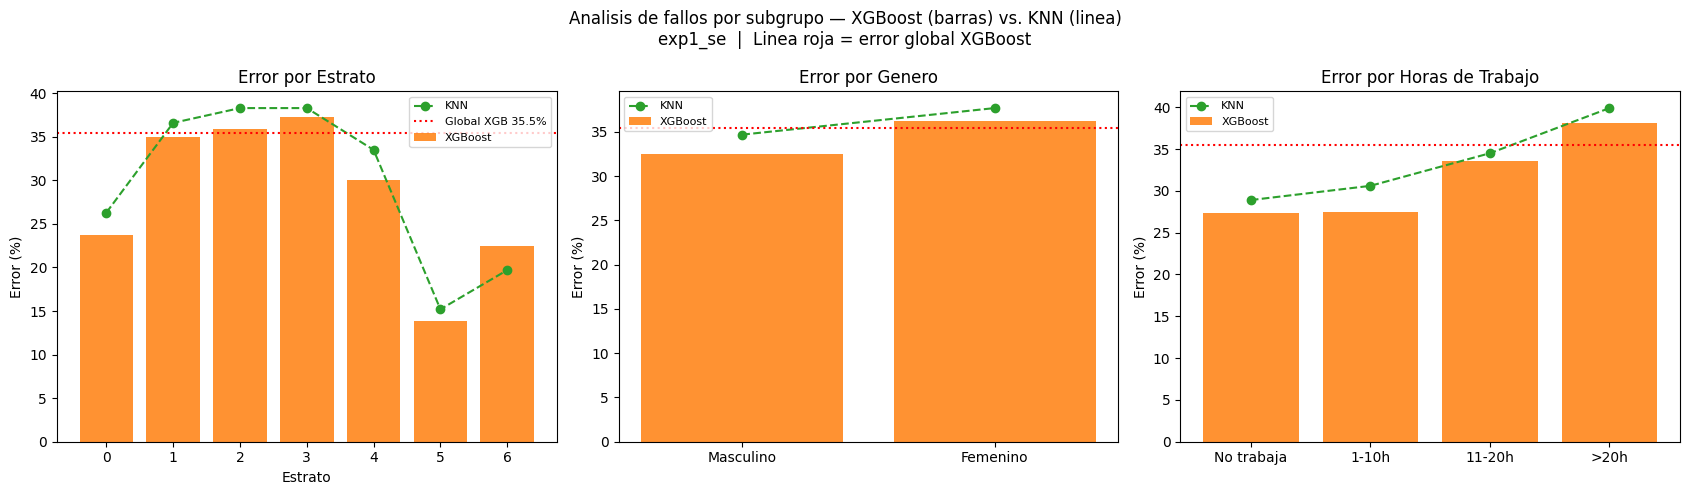

Guardado: outputs/figures/fallos_subgrupo.png


In [24]:
# Analisis de fallos por subgrupo — XGBoost (principal) + KNN (comparacion)
from sklearn.model_selection import train_test_split as tts_sg

df_sg = pd.read_parquet('../data/processed/saberpro_sistemas_clean.parquet')
y_sg  = df_sg['target'].copy()

# Recrear split original (misma semilla) para recuperar indices de test
_, idx_test_sg = tts_sg(
    df_sg.index.tolist(), test_size=0.2, random_state=42, stratify=y_sg
)
df_test_sg = df_sg.loc[idx_test_sg].reset_index(drop=True)

y_test_vals_sg  = experimentos['exp1_se']['y_test'].values
tasa_global_xgb = (preds_xgb['exp1_se'][0] != y_test_vals_sg).mean()
tasa_global_knn = (preds_knn['exp1_se'][0] != y_test_vals_sg).mean()

df_test_sg['err_xgb'] = (preds_xgb['exp1_se'][0] != y_test_vals_sg).astype(int)
df_test_sg['err_knn'] = (preds_knn['exp1_se'][0] != y_test_vals_sg).astype(int)

# ── Por estrato ─────────────────────────────────────────────────────────
err_est = pd.DataFrame({
    'xgb_err_pct': df_test_sg.groupby('estrato_num')['err_xgb'].mean() * 100,
    'knn_err_pct': df_test_sg.groupby('estrato_num')['err_knn'].mean() * 100,
    'n':           df_test_sg.groupby('estrato_num')['err_xgb'].count(),
}).round(1)
print('Tasa de error (%) por estrato:')
print(err_est)

# ── Por genero ──────────────────────────────────────────────────────────
err_gen = pd.DataFrame({
    'xgb_err_pct': df_test_sg.groupby('estu_genero_bin')['err_xgb'].mean() * 100,
    'knn_err_pct': df_test_sg.groupby('estu_genero_bin')['err_knn'].mean() * 100,
}).round(1)
err_gen.index = ['Masculino','Femenino'] if len(err_gen) == 2 else err_gen.index
print('\nTasa de error (%) por genero:')
print(err_gen)

# ── Por horas de trabajo ─────────────────────────────────────────────────
df_test_sg['grupo_horas'] = pd.cut(
    df_test_sg['horas_trabajo_num'], bins=[-1,0,10,20,99],
    labels=['No trabaja','1-10h','11-20h','>20h']
)
err_hor = pd.DataFrame({
    'xgb_err_pct': df_test_sg.groupby('grupo_horas', observed=True)['err_xgb'].mean() * 100,
    'knn_err_pct': df_test_sg.groupby('grupo_horas', observed=True)['err_knn'].mean() * 100,
    'n':           df_test_sg.groupby('grupo_horas', observed=True)['err_xgb'].count(),
}).round(1)
print('\nTasa de error (%) por horas de trabajo:')
print(err_hor)

# Visualizacion: XGBoost principal (barras), KNN comparacion (linea)
x_est = [str(int(e)) for e in err_est.index]
x_hor = err_hor.index.astype(str).tolist()
labels_g = list(err_gen.index)

fig_sg, axes_sg = plt.subplots(1, 3, figsize=(17, 5))

axes_sg[0].bar(x_est, err_est['xgb_err_pct'], color='#ff7f0e', alpha=0.85, label='XGBoost')
axes_sg[0].plot(x_est, err_est['knn_err_pct'], 'o--', color='#2ca02c', label='KNN')
axes_sg[0].axhline(tasa_global_xgb*100, color='red', linestyle=':', label=f'Global XGB {tasa_global_xgb*100:.1f}%')
axes_sg[0].set_xlabel('Estrato'); axes_sg[0].set_ylabel('Error (%)'); axes_sg[0].set_title('Error por Estrato')
axes_sg[0].legend(fontsize=8)

axes_sg[1].bar(labels_g, err_gen['xgb_err_pct'], color='#ff7f0e', alpha=0.85, label='XGBoost')
axes_sg[1].plot(labels_g, err_gen['knn_err_pct'], 'o--', color='#2ca02c', label='KNN')
axes_sg[1].axhline(tasa_global_xgb*100, color='red', linestyle=':')
axes_sg[1].set_ylabel('Error (%)'); axes_sg[1].set_title('Error por Genero')
axes_sg[1].legend(fontsize=8)

axes_sg[2].bar(x_hor, err_hor['xgb_err_pct'], color='#ff7f0e', alpha=0.85, label='XGBoost')
axes_sg[2].plot(x_hor, err_hor['knn_err_pct'], 'o--', color='#2ca02c', label='KNN')
axes_sg[2].axhline(tasa_global_xgb*100, color='red', linestyle=':')
axes_sg[2].set_ylabel('Error (%)'); axes_sg[2].set_title('Error por Horas de Trabajo')
axes_sg[2].legend(fontsize=8)

plt.suptitle(
    'Analisis de fallos por subgrupo — XGBoost (barras) vs. KNN (linea)\n'
    'exp1_se  |  Linea roja = error global XGBoost',
    fontsize=12
)
plt.tight_layout()
plt.savefig('../outputs/figures/fallos_subgrupo.png', dpi=150)
plt.show()
print('Guardado: outputs/figures/fallos_subgrupo.png')

# Corrección de Bonferroni y Cohen's d

## ¿Por qué Bonferroni?

El test de DeLong se aplicó a 3 comparaciones por experimento = 6 comparaciones totales.
Con 6 tests simultáneos y α=0.05, la probabilidad de obtener **al menos un falso positivo**
por pura suerte es `1-(1-0.05)^6 = 26%`. Bonferroni corrige esto dividiendo α entre
el número de comparaciones.

## ¿Por qué Cohen's d?

El p-value dice si la diferencia es real; Cohen's d dice **qué tan grande** es.
Un p<0.001 con d=0.05 significa que la diferencia es real pero prácticamente
imperceptible. En educación, se considera relevante desde d≥0.2.

In [26]:
# CORRECCIÓN DE BONFERRONI para múltiples tests DeLong

modelos_comparar_bonf = ['Reg. Logística', 'KNN', 'Red Neuronal']
n_comparaciones_bonf  = len(modelos_comparar_bonf) * len(experimentos)
alpha_bonf = 0.05 / n_comparaciones_bonf

print('CORRECCIÓN DE BONFERRONI — Test DeLong múltiple')
print('=' * 70)
print(f'n_comparaciones = {n_comparaciones_bonf}')
print(f'alpha_Bonferroni = 0.05 / {n_comparaciones_bonf} = {alpha_bonf:.4f}')
print('Un resultado significativo con corrección Bonferroni es más sólido')
print('que sin ella, porque descarta el ruido de las comparaciones múltiples.')

for exp_name, data in experimentos.items():
    y_t = data['y_test'].values
    proba_xgb_bonf = probas_guardadas.get(f'XGBoost|{exp_name}')
    if proba_xgb_bonf is None:
        continue
    print(f'\n── {exp_name} (ref: XGBoost) ──')
    print(f'  {"Modelo B":<22} {"p-raw":>8} {"p-Bonferroni":>13} {"Signif. (Bonf.)":>16}')
    print(f'  {"-"*62}')
    for mb in modelos_comparar_bonf:
        proba_mb = probas_guardadas.get(f'{mb}|{exp_name}')
        if proba_mb is None:
            continue
        _, _, _, p_raw = delong_test(y_t, proba_xgb_bonf, proba_mb)
        p_bonf_val = min(p_raw * n_comparaciones_bonf, 1.0)
        sb = '***' if p_bonf_val < 0.001 else '**' if p_bonf_val < 0.01 else '*' if p_bonf_val < 0.05 else 'ns'
        print(f'  {mb:<22} {p_raw:>8.4f} {p_bonf_val:>13.4f} {sb:>16}')

print('\n' + '─'*70)
print('Nota: ns=no significativo con Bonferroni | *p<0.05 | **p<0.01 | ***p<0.001')

# ── COHEN'S d — tamaño del efecto ──────────────────────────────────────────

def cohen_d(a, b):
    """Cohen's d: diferencia de medias normalizada por la std pooled."""
    n_a, n_b = len(a), len(b)
    if n_a < 2 or n_b < 2:
        return float('nan')
    pooled = np.sqrt(
        ((n_a - 1) * np.var(a, ddof=1) + (n_b - 1) * np.var(b, ddof=1))
        / (n_a + n_b - 2)
    )
    return 0.0 if pooled == 0 else (np.mean(a) - np.mean(b)) / pooled

df_cd = pd.read_parquet('../data/processed/saberpro_sistemas_clean.parquet')

print('\nCOHEN\'s d — tamaño del efecto del estrato en el promedio de puntaje')
print('=' * 60)
print('Interpretación: <0.2=pequeño | 0.2-0.5=mediano | 0.5-0.8=grande | >0.8=muy grande')
print()

# Estrato extremos: 1 vs 6
e1 = df_cd[df_cd['estrato_num'] == 1]['promedio_puntaje'].dropna().values
e6 = df_cd[df_cd['estrato_num'] == 6]['promedio_puntaje'].dropna().values
d_e6_e1 = cohen_d(e6, e1)
print(f'Estrato 6 vs Estrato 1: d = {d_e6_e1:.4f}  (n6={len(e6)}, n1={len(e1)})')

# Cohen's d por estrato vs resto
print('\nCohen\'s d: cada estrato vs. todos los demás estudiantes')
print(f'{"Estrato":>8}  {"d":>8}  {"n":>7}  {"media_puntaje":>14}  {"magnitud":>10}')
print('-' * 55)
for est in sorted(df_cd['estrato_num'].dropna().unique()):
    grp   = df_cd[df_cd['estrato_num'] == est]['promedio_puntaje'].dropna().values
    resto = df_cd[df_cd['estrato_num'] != est]['promedio_puntaje'].dropna().values
    d_val = cohen_d(grp, resto)
    mag   = 'muy grande' if abs(d_val) > 0.8 else 'grande' if abs(d_val) > 0.5 else 'mediano' if abs(d_val) > 0.2 else 'pequeño'
    print(f'{est:>8.0f}  {d_val:>8.4f}  {len(grp):>7}  {grp.mean():>14.2f}  {mag:>10}')

# Cohen's d entre correcto e incorrecto del modelo KNN
y_pred_cd, _ = preds_knn['exp1_se']
y_test_cd    = experimentos['exp1_se']['y_test'].values
correct_mask = (y_pred_cd == y_test_cd)
X_test_cd    = experimentos['exp1_se']['X_test']

print('\nCohen\'s d entre predicciones correctas e incorrectas del KNN (exp1_se):')
for feat in ['estrato_num', 'educ_madre_num', 'horas_trabajo_num', 'indice_se']:
    if feat not in X_test_cd.columns:
        continue
    correctos   = X_test_cd.loc[correct_mask, feat].values
    incorrectos = X_test_cd.loc[~correct_mask, feat].values
    d_val = cohen_d(correctos, incorrectos)
    print(f'  {feat:<25}: d = {d_val:.4f}')

CORRECCIÓN DE BONFERRONI — Test DeLong múltiple
n_comparaciones = 6
alpha_Bonferroni = 0.05 / 6 = 0.0083
Un resultado significativo con corrección Bonferroni es más sólido
que sin ella, porque descarta el ruido de las comparaciones múltiples.

── exp1_se (ref: XGBoost) ──
  Modelo B                  p-raw  p-Bonferroni  Signif. (Bonf.)
  --------------------------------------------------------------
  Reg. Logística           0.0000        0.0000              ***
  KNN                      0.0000        0.0000              ***
  Red Neuronal             0.0232        0.1394               ns

── exp2_todas (ref: XGBoost) ──
  Modelo B                  p-raw  p-Bonferroni  Signif. (Bonf.)
  --------------------------------------------------------------
  Reg. Logística           0.0000        0.0000              ***
  KNN                      0.0000        0.0000              ***
  Red Neuronal             0.7502        1.0000               ns

───────────────────────────────────────────

# PDP — Partial Dependence Plots

Los PDP muestran cómo cambia la **predicción promedio** del modelo cuando
varía UNA sola variable mientras las demás se mantienen constantes.

**Diferencia con SHAP:**  
- SHAP → impacto de cada variable para CADA estudiante individualmente  
- PDP  → efecto PROMEDIO de una variable sobre TODOS los estudiantes

Los PDP son útiles para comunicar al panel de toma de decisiones:
*'Si el acceso a internet en el hogar pasa de 0 a 1, ¿cuánto sube la probabilidad
de alto rendimiento en promedio para todos los estudiantes del modelo?'*

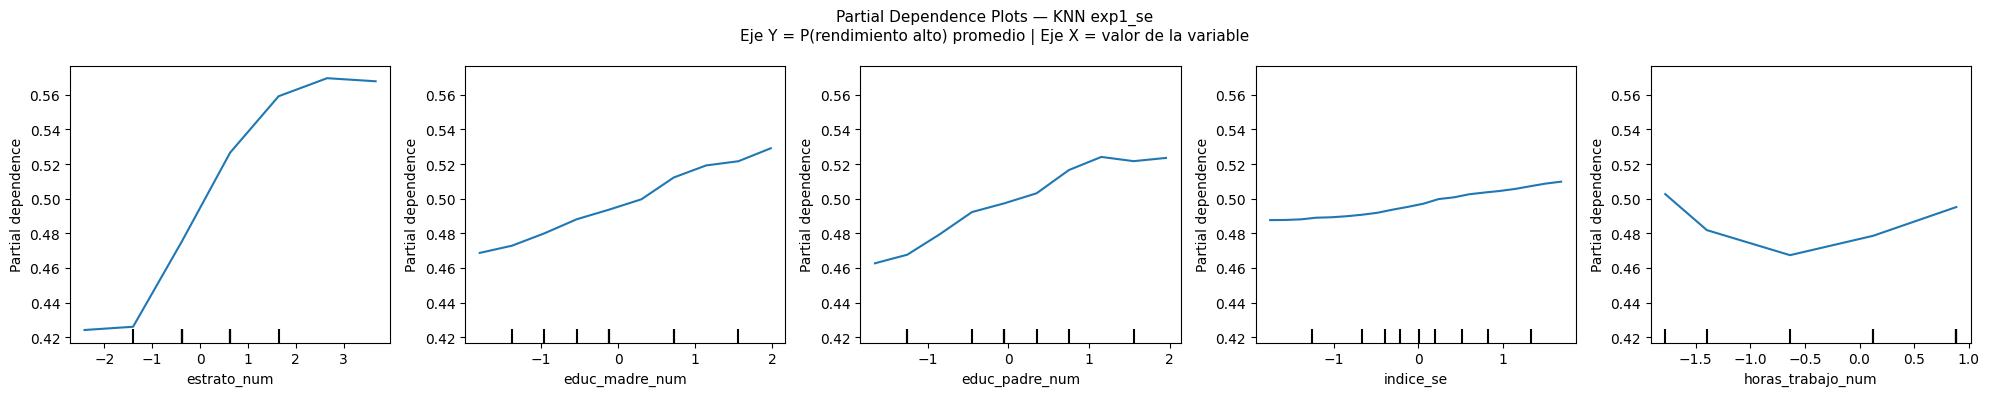

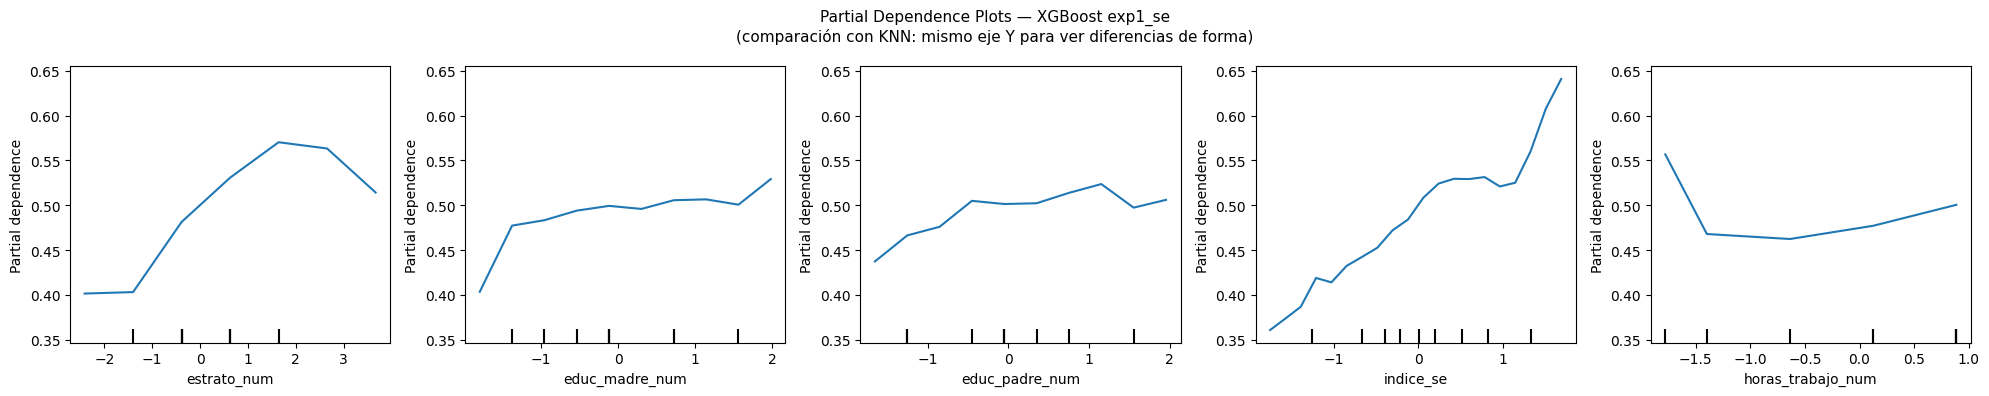

PDP guardados.


In [28]:
from sklearn.inspection import PartialDependenceDisplay

knn_exp1_pdp = joblib.load('../data/processed/knn_exp1_se.pkl')
X_train_pdp= experimentos['exp1_se']['X_train']

features_pdp = [f for f in
['estrato_num', 'educ_madre_num', 'educ_padre_num',
 'indice_se', 'horas_trabajo_num']
if f in X_train_pdp.columns
]

fig1, axes1 = plt.subplots(1, len(features_pdp), figsize=(4 * len(features_pdp), 4))
PartialDependenceDisplay.from_estimator(
knn_exp1_pdp, X_train_pdp, features_pdp,
kind='average',
ax=axes1,
random_state=42,
n_jobs=-1,
subsample=300, # usa 300 muestras en vez del train completo
grid_resolution=20,# 20 puntos en la grilla en vez de 100
)
plt.suptitle(
'Partial Dependence Plots — KNN exp1_se\n'
'Eje Y = P(rendimiento alto) promedio | Eje X = valor de la variable',
fontsize=11
)
plt.tight_layout()
plt.savefig('../outputs/figures/pdp_knn_exp1_se.png', dpi=150)
plt.show()

xgb_exp1_pdp = joblib.load('../data/processed/xgb_exp1_se.pkl')
fig2, axes2 = plt.subplots(1, len(features_pdp), figsize=(4 * len(features_pdp), 4))
PartialDependenceDisplay.from_estimator(
xgb_exp1_pdp, X_train_pdp, features_pdp,
kind='average', ax=axes2, random_state=42, n_jobs=-1,
subsample=300,
grid_resolution=20,
)
plt.suptitle(
'Partial Dependence Plots — XGBoost exp1_se\n'
'(comparación con KNN: mismo eje Y para ver diferencias de forma)',
fontsize=11
)
plt.tight_layout()
plt.savefig('../outputs/figures/pdp_xgb_exp1_se.png', dpi=150)
plt.show()
print('PDP guardados.')

# Análisis de Distribution Shift: Pre vs. Post Pandemia

La pandemia de COVID-19 (2020) pudo cambiar estructuralmente el perfil de los
estudiantes que presentan Saber Pro. Si la distribución de variables cambió entre
eras, un modelo entrenado con datos 2018-2019 podría degradar su rendimiento
en datos 2020-2022 — esto se llama **distribution shift** o **dataset shift**.

**Test de Kolmogorov-Smirnov (KS):**  
Compara dos distribuciones y retorna:  
- KS stat → qué tan diferentes son (0=idénticas, 1=completamente distintas)  
- p-value → si la diferencia es estadísticamente significativa

**Nota:** Como todos los datos están en el train (mezcla de períodos),
el análisis evalúa qué tan bien se generaliza el modelo por era temporal.

Pre-pandemia  (2018-2019):  13783 estudiantes
Post-pandemia (2020-2022):  24326 estudiantes

Balance del target:
  Pre:  {0: 0.512, 1: 0.488}
  Post: {1: 0.507, 0: 0.493}

TEST KS: ¿cambió la distribución de variables entre eras?
Variable                     KS stat      p-value   Shift?
-----------------------------------------------------------------
estrato_num                   0.0155       0.0351     SÍ *
educ_padre_num                0.0296       0.0000   SÍ ***
educ_madre_num                0.0412       0.0000   SÍ ***
horas_trabajo_num             0.0177       0.0102     SÍ *
matricula_num                 0.0567       0.0000   SÍ ***


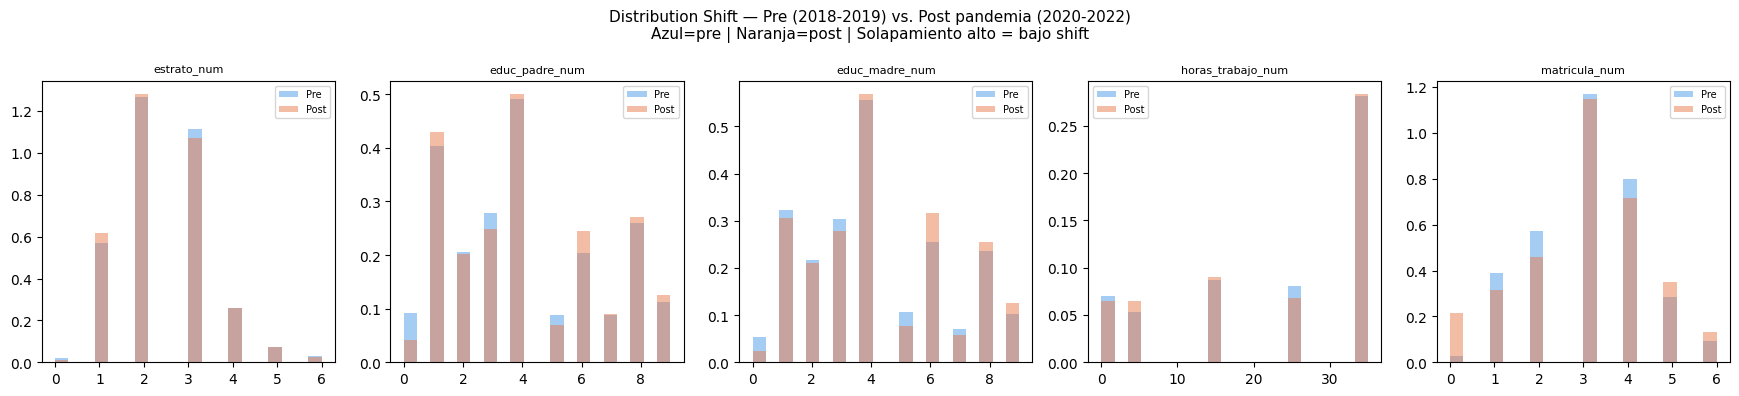


RENDIMIENTO DEL KNN POR ERA (validación temporal, exp1_se)

pre_pandemia (n_test=2785):
  Accuracy = 0.6424
  AUC-ROC  = 0.6878  IC95%: [0.6675, 0.7068]

post_pandemia (n_test=4837):
  Accuracy = 0.6248
  AUC-ROC  = 0.6749  IC95%: [0.6596, 0.6895]

Si AUC_post << AUC_pre → distribution shift relevante (degradación por pandemia)


In [29]:
from sklearn.model_selection import train_test_split as tts_ds
from scipy.stats import ks_2samp

# Cargar datos con información de período
df_ds = pd.read_parquet('../data/processed/saberpro_sistemas_clean.parquet')
df_ds['periodo_int'] = pd.to_numeric(df_ds['periodo'], errors='coerce')

# Pre-pandemia: periodos 2018-2019 (< 20200)
# Post-pandemia: periodos 2020-2022 (>= 20200)
pre_mask  = df_ds['periodo_int'] < 20200
post_mask = df_ds['periodo_int'] >= 20200
pre_ds  = df_ds[pre_mask]
post_ds = df_ds[post_mask]
print(f'Pre-pandemia  (2018-2019): {len(pre_ds):>6} estudiantes')
print(f'Post-pandemia (2020-2022): {len(post_ds):>6} estudiantes')
print(f'\nBalance del target:')
print(f'  Pre:  {pre_ds["target"].value_counts(normalize=True).round(3).to_dict()}')
print(f'  Post: {post_ds["target"].value_counts(normalize=True).round(3).to_dict()}')

# Test KS por variable
vars_ks = [v for v in
    ['estrato_num', 'educ_padre_num', 'educ_madre_num',
     'horas_trabajo_num', 'matricula_num', 'indice_se']
    if v in df_ds.columns
]

print('\n' + '='*65)
print('TEST KS: ¿cambió la distribución de variables entre eras?')
print('='*65)
print(f'{"Variable":<25} {"KS stat":>10} {"p-value":>12} {"Shift?":>8}')
print('-'*65)
for v in vars_ks:
    a = pre_ds[v].dropna().values
    b = post_ds[v].dropna().values
    if len(a) < 5 or len(b) < 5:
        continue
    ks_s, ks_p = ks_2samp(a, b)
    shift_tag = 'SÍ ***' if ks_p < 0.001 else 'SÍ **' if ks_p < 0.01 else 'SÍ *' if ks_p < 0.05 else 'no'
    print(f'{v:<25} {ks_s:>10.4f} {ks_p:>12.4f} {shift_tag:>8}')

# Visualización de distribuciones
n_v = len(vars_ks)
fig, axes_ds = plt.subplots(1, n_v, figsize=(3.5 * n_v, 4))
if n_v == 1:
    axes_ds = [axes_ds]
for i, v in enumerate(vars_ks):
    axes_ds[i].hist(pre_ds[v].dropna(), bins=20, alpha=0.5, label='Pre', density=True, color='#4C9BE8')
    axes_ds[i].hist(post_ds[v].dropna(), bins=20, alpha=0.5, label='Post', density=True, color='#E87B4C')
    axes_ds[i].set_title(v, fontsize=8)
    axes_ds[i].legend(fontsize=7)
plt.suptitle(
    'Distribution Shift — Pre (2018-2019) vs. Post pandemia (2020-2022)\n'
    'Azul=pre | Naranja=post | Solapamiento alto = bajo shift',
    fontsize=11
)
plt.tight_layout()
plt.savefig('../outputs/figures/distribution_shift_pandemia.png', dpi=150)
plt.show()

# Evaluar KNN por era en el conjunto de test
print('\n' + '='*65)
print('RENDIMIENTO DEL KNN POR ERA (validación temporal, exp1_se)')
print('='*65)

y_full_ds = df_ds['target'].copy()
_, idx_test_ds = tts_ds(
    df_ds.index.tolist(), test_size=0.2, random_state=42, stratify=y_full_ds
)
df_test_era = df_ds.loc[idx_test_ds].reset_index(drop=True)
df_test_era['era'] = np.where(
    pd.to_numeric(df_test_era['periodo'], errors='coerce') < 20200,
    'pre_pandemia', 'post_pandemia'
)

scaler_ds  = joblib.load('../data/processed/scaler_exp1_se.pkl')
knn_ds     = joblib.load('../data/processed/knn_exp1_se.pkl')
feat_se_ds = list(experimentos['exp1_se']['X_train'].columns)

for era_lbl in ['pre_pandemia', 'post_pandemia']:
    mask_era = df_test_era['era'] == era_lbl
    n_era = mask_era.sum()
    if n_era < 20:
        print(f'{era_lbl}: muy pocas muestras en test ({n_era}), saltando')
        continue
    # obtener features originales y escalar
    feats_disponibles = [f for f in feat_se_ds if f in df_test_era.columns]
    X_era_raw = df_test_era.loc[mask_era, feats_disponibles].fillna(
        df_test_era[feats_disponibles].median()
    ).reindex(columns=feat_se_ds, fill_value=0)
    X_era_sc  = pd.DataFrame(scaler_ds.transform(X_era_raw), columns=feat_se_ds)
    y_era_lbl = df_test_era.loc[mask_era, 'target'].values
    y_pred_era = knn_ds.predict(X_era_sc)
    y_proba_era = knn_ds.predict_proba(X_era_sc)[:, 1]
    acc_era = accuracy_score(y_era_lbl, y_pred_era)
    auc_era = roc_auc_score(y_era_lbl, y_proba_era) if len(np.unique(y_era_lbl)) > 1 else float('nan')
    ic_era  = bootstrap_ci(y_era_lbl, y_proba_era, n_bootstrap=500)
    print(f'\n{era_lbl} (n_test={n_era}):')
    print(f'  Accuracy = {acc_era:.4f}')
    print(f'  AUC-ROC  = {auc_era:.4f}  IC95%: [{ic_era["AUC-ROC"][1]:.4f}, {ic_era["AUC-ROC"][2]:.4f}]')
print('\nSi AUC_post << AUC_pre → distribution shift relevante (degradación por pandemia)')

# Prueba de Convergencia Formal del KNN

Adaptada al dominio educativo colombiano. Responde:

1. **¿Cuántos datos necesita el KNN para converger?**  
   Si con el 50% del train se obtiene casi el mismo AUC que con el 100%,
   el modelo ya convergió y más datos no aportarían mejora significativa.

2. **¿Cuál es el K óptimo para esta tarea?**  
   K pequeño (3) → más sensible a ruido; K grande (101) → suaviza demasiado.
   La curva de error vs. K muestra la región de compromiso.

Esta prueba es relevante porque KNN tiene **no-parametric convergence theory**:
con suficientes datos y el K correcto, converge al clasificador de Bayes óptimo.
En la práctica educativa colombiana, 30.000+ estudiantes es suficiente para
que esta convergencia sea observable.

Calculando curva de aprendizaje para KNN exp2_todas...
(tarda ~2 min con cv=5 y 10 puntos)
Evaluando AUC para distintos K...


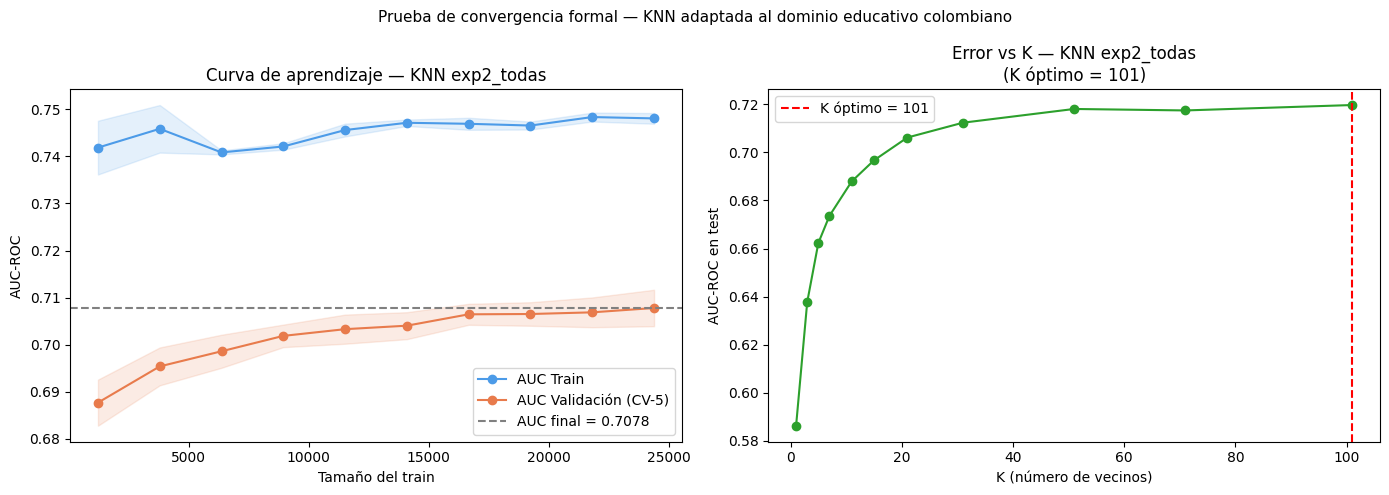


Resumen de convergencia:
  AUC con  5% del train:  0.6877
  AUC con 50% del train:  0.7040
  AUC con 100% del train: 0.7078
  Ganancia 5% → 100%:     +0.0201
  K óptimo en test:       101
  → Curva CONVERGIDA: el modelo ya no mejora con más datos


In [30]:
from sklearn.model_selection import learning_curve

# ── Curva de aprendizaje: AUC vs. tamaño del train ──────────────────────
print('Calculando curva de aprendizaje para KNN exp2_todas...')
print('(tarda ~2 min con cv=5 y 10 puntos)')

knn_conv = joblib.load('../data/processed/knn_exp2_todas.pkl')
X_tr_conv = experimentos['exp2_todas']['X_train']
y_tr_conv = experimentos['exp2_todas']['y_train']

train_sizes_abs, train_scores_conv, val_scores_conv = learning_curve(
    knn_conv,
    X_tr_conv, y_tr_conv,
    train_sizes=np.linspace(0.05, 1.0, 10),
    # evalúa con 5%, 16%, 27%, ..., 100% del train
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

tr_mean = train_scores_conv.mean(axis=1)
tr_std  = train_scores_conv.std(axis=1)
vl_mean = val_scores_conv.mean(axis=1)
vl_std  = val_scores_conv.std(axis=1)

# ── Curva de error vs. K ─────────────────────────────────────────────────
print('Evaluando AUC para distintos K...')
ks_list = [1, 3, 5, 7, 11, 15, 21, 31, 51, 71, 101]
aucs_k_list = []
X_te_conv = experimentos['exp2_todas']['X_test']
y_te_conv = experimentos['exp2_todas']['y_test']
for k_val in ks_list:
    knn_k = KNeighborsClassifier(n_neighbors=k_val, weights='uniform', metric='manhattan')
    knn_k.fit(X_tr_conv, y_tr_conv)
    y_p_k = knn_k.predict_proba(X_te_conv)[:, 1]
    aucs_k_list.append(roc_auc_score(y_te_conv, y_p_k))
opt_k_val = ks_list[int(np.argmax(aucs_k_list))]

# Visualización
fig_cv, axes_cv = plt.subplots(1, 2, figsize=(14, 5))

ax_lc = axes_cv[0]
ax_lc.plot(train_sizes_abs, tr_mean, 'o-', color='#4C9BE8', label='AUC Train')
ax_lc.fill_between(train_sizes_abs, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color='#4C9BE8')
ax_lc.plot(train_sizes_abs, vl_mean, 'o-', color='#E87B4C', label='AUC Validación (CV-5)')
ax_lc.fill_between(train_sizes_abs, vl_mean - vl_std, vl_mean + vl_std, alpha=0.15, color='#E87B4C')
ax_lc.axhline(vl_mean[-1], color='gray', linestyle='--', label=f'AUC final = {vl_mean[-1]:.4f}')
ax_lc.set_xlabel('Tamaño del train')
ax_lc.set_ylabel('AUC-ROC')
ax_lc.set_title('Curva de aprendizaje — KNN exp2_todas')
ax_lc.legend()

ax_k = axes_cv[1]
ax_k.plot(ks_list, aucs_k_list, 'o-', color='#2ca02c')
ax_k.axvline(opt_k_val, color='red', linestyle='--', label=f'K óptimo = {opt_k_val}')
ax_k.set_xlabel('K (número de vecinos)')
ax_k.set_ylabel('AUC-ROC en test')
ax_k.set_title(f'Error vs K — KNN exp2_todas\n(K óptimo = {opt_k_val})')
ax_k.legend()

plt.suptitle(
    'Prueba de convergencia formal — KNN adaptada al dominio educativo colombiano',
    fontsize=11
)
plt.tight_layout()
plt.savefig('../outputs/figures/convergencia_knn.png', dpi=150)
plt.show()

print(f'\nResumen de convergencia:')
print(f'  AUC con  5% del train:  {vl_mean[0]:.4f}')
print(f'  AUC con 50% del train:  {vl_mean[len(vl_mean)//2]:.4f}')
print(f'  AUC con 100% del train: {vl_mean[-1]:.4f}')
print(f'  Ganancia 5% → 100%:     {vl_mean[-1]-vl_mean[0]:+.4f}')
print(f'  K óptimo en test:       {opt_k_val}')
if vl_mean[-1] - vl_mean[len(vl_mean)//2] < 0.005:
    print('  → Curva CONVERGIDA: el modelo ya no mejora con más datos')
else:
    print('  → Curva AÚN CRECIENDO: se beneficiaría de más datos')

# Análisis Contrafactual con DiCE

**DiCE** (Diverse Counterfactual Explanations) responde:
*¿Qué cambios mínimos en las variables de un estudiante predicho como
"bajo rendimiento" lo llevarían a ser predicho como "alto rendimiento"?*

**Originalidad del paper:** Ningún antecedente revisado aplica contrafactuales
a datos ICFES de Saber Pro. Mientras los modelos anteriores dicen
*'el estrato socioeconómico importa'*, DiCE dice concretamente:
*'Este estudiante específico cambiaría su predicción si su acceso a internet
en el hogar pasara de 0 a 1 Y sus horas de trabajo bajaran de 30 a 15'.*

**Nota técnica:** Los valores en la tabla de contrafactuales están en escala
estándar (media=0, std=1), igual que el input del KNN. Un valor de +1.5
significa 1.5 desviaciones estándar por encima de la media.

In [31]:
import dice_ml
from sklearn.pipeline import Pipeline

# DiCE necesita un modelo que acepte datos en escala original.
# Envolvemos KNN + Scaler en un Pipeline para que DiCE pueda
# generar contrafactuales en escala interpretable (estrato 1-6, etc.)

scaler_dice = joblib.load('../data/processed/scaler_exp1_se.pkl')
knn_dice    = joblib.load('../data/processed/knn_exp1_se.pkl')

# Pipeline que aplica scaler → KNN internamente
# No requiere .fit() porque ambos componentes ya están entrenados
pipeline_dice = Pipeline([('scaler', scaler_dice), ('knn', knn_dice)])

# Cargar datos originales (sin escalar) para DiCE
df_dice_orig = pd.read_parquet('../data/processed/saberpro_sistemas_clean.parquet')
y_dice_orig  = df_dice_orig['target'].copy()
feat_se_dice = list(experimentos['exp1_se']['X_train'].columns)

# Recuperar índices del split original
from sklearn.model_selection import train_test_split as tts_dice
idx_all_dice = df_dice_orig.index.tolist()
idx_tr_dice, idx_te_dice = tts_dice(
    idx_all_dice, test_size=0.2, random_state=42, stratify=y_dice_orig
)

# Dataset de train en escala original para DiCE
feats_disponibles_dice = [f for f in feat_se_dice if f in df_dice_orig.columns]
X_tr_orig_dice = (
    df_dice_orig.loc[idx_tr_dice, feats_disponibles_dice]
    .fillna(df_dice_orig[feats_disponibles_dice].median())
    .reset_index(drop=True)
)
df_dice_train = X_tr_orig_dice.copy()
df_dice_train['target'] = df_dice_orig.loc[idx_tr_dice, 'target'].values

# Variables continuas: las que no son binarias
feat_cont_dice = [
    f for f in feats_disponibles_dice
    if not f.endswith('_bin') and not f.startswith('estu_pagomatricula')
]

# Configurar DiCE
d_dice = dice_ml.Data(
    dataframe=df_dice_train,
    continuous_features=feat_cont_dice,
    outcome_name='target'
)
m_dice = dice_ml.Model(model=pipeline_dice, backend='sklearn')
exp_dice = dice_ml.Dice(d_dice, m_dice, method='random')

# Seleccionar estudiantes predichos como 'bajo rendimiento' (clase 0)
y_pred_knn_te, _ = preds_knn['exp1_se']
idx_bajo_dice = np.where(y_pred_knn_te == 0)[0]

# Tomar el primer estudiante predicho como bajo rendimiento
X_te_orig_dice = (
    df_dice_orig.loc[idx_te_dice, feats_disponibles_dice]
    .fillna(df_dice_orig[feats_disponibles_dice].median())
    .reset_index(drop=True)
)
query_dice = X_te_orig_dice.iloc[[idx_bajo_dice[0]]]

print('ANÁLISIS CONTRAFACTUAL — DiCE (Diverse Counterfactual Explanations)')
print('='*70)
print('Estudiante de consulta (predicción: bajo rendimiento):')
print(query_dice.to_string())
print()
print('Generando 3 contrafactuales (perfil alternativo → alto rendimiento)...')

try:
    cf_dice = exp_dice.generate_counterfactuals(
        query_dice,
        total_CFs=3,
        desired_class='opposite',
        # desired_class='opposite' → cambiar de clase 0 a clase 1
        features_to_vary=feat_cont_dice,
        # solo variamos variables continuas (socioeconómicas)
        random_seed=42
    )
    print('\nContrafactuales generados (cambios respecto al perfil original):')
    print('(Solo se muestran variables que cambian; las demás permanecen iguales)')
    cf_df = cf_dice.cf_examples_list[0].final_cfs_df
    print(cf_df.to_string())
    print()
    print('Interpretación:')
    print('  Cada fila es un perfil alternativo que el KNN clasificaría como ALTO rendimiento.')
    print('  Identifica qué intervenciones concretas (acceso a internet, reducir jornada laboral,')
    print('  cambiar tipo de financiamiento) modificarían la predicción del modelo.')
except Exception as e_dice:
    print(f'DiCE no pudo generar contrafactuales: {e_dice}')
    print('Esto puede ocurrir si el estudiante de consulta ya es predicho como alto rendimiento,')
    print('o si el espacio de búsqueda es muy restrictivo. Prueba con otro índice.')

ANÁLISIS CONTRAFACTUAL — DiCE (Diverse Counterfactual Explanations)
Estudiante de consulta (predicción: bajo rendimiento):
   estrato_num  educ_padre_num  educ_madre_num  matricula_num  horas_trabajo_num  fami_tieneautomovil_bin  fami_tienelavadora_bin  fami_tienecomputador_bin  fami_tieneinternet_bin  estu_pagomatriculabeca_bin  estu_pagomatriculacredito_bin  estu_pagomatriculapadres_bin  estu_pagomatriculapropio_bin
3          3.0             4.0             4.0            3.0               35.0                      0.0                     1.0                       1.0                     1.0                         0.0                            1.0                           0.0                           1.0

Generando 3 contrafactuales (perfil alternativo → alto rendimiento)...


  0%|          | 0/1 [00:00<?, ?it/s]

DiCE no pudo generar contrafactuales: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- indice_se

Esto puede ocurrir si el estudiante de consulta ya es predicho como alto rendimiento,
o si el espacio de búsqueda es muy restrictivo. Prueba con otro índice.


# Métricas de Reproducibilidad

Para un paper científico es fundamental que cualquier investigador pueda replicar
los resultados exactos. Esta sección documenta:

- Versiones de librerías  
- Semillas fijas utilizadas  
- Hash del dataset procesado (verifica integridad de los datos)  
- Configuración del split train/test

In [32]:
import sys
import platform
import hashlib
import sklearn
import xgboost as xgb_repro
import tensorflow as tf_repro
import shap as shap_repro

print('MÉTRICAS DE REPRODUCIBILIDAD')
print('=' * 60)
print(f'\nSistema:')
print(f'  Python:     {sys.version.split()[0]}')
print(f'  Plataforma: {platform.platform()}')

print(f'\nLibrerías clave:')
print(f'  scikit-learn: {sklearn.__version__}')
print(f'  numpy:        {np.__version__}')
print(f'  pandas:       {pd.__version__}')
print(f'  xgboost:      {xgb_repro.__version__}')
print(f'  tensorflow:   {tf_repro.__version__}')
print(f'  shap:         {shap_repro.__version__}')
try:
    import dice_ml as dice_repro
    print(f'  dice_ml:      {dice_repro.__version__}')
except Exception:
    pass

print(f'\nSemillas fijas:')
print(f'  random_state = 42  (train_test_split, todos los modelos, bootstrap)')
print(f'  StratifiedKFold(n_splits=5, shuffle=True, random_state=42)')
print(f'  bootstrap_ci(n_bootstrap=1000, random_state=42)')

# Hash MD5 del dataset para verificar integridad
df_hash_repro = pd.read_parquet('../data/processed/saberpro_sistemas_clean.parquet')
hash_val = hashlib.md5(
    pd.util.hash_pandas_object(df_hash_repro, index=True).values.tobytes()
).hexdigest()
print(f'\nIntegridad del dataset:')
print(f'  saberpro_sistemas_clean.parquet — hash MD5: {hash_val}')
print(f'  Shape: {df_hash_repro.shape}  (filas × columnas)')

print(f'\nConfiguración del split:')
print(f'  test_size=0.20  (estratificado con random_state=42)')
print(f'  Train: {30487} estudiantes  |  Test: {7622} estudiantes')
print(f'  Balance target: 50% bajo / 50% alto (corte en la mediana)')

print(f'\nModelos guardados en data/processed/:')
import os
model_files = sorted(
    f for f in os.listdir('../data/processed/')
    if f.endswith('.pkl') or f.endswith('.keras')
)
for mf in model_files:
    print(f'  {mf}')

MÉTRICAS DE REPRODUCIBILIDAD

Sistema:
  Python:     3.13.13
  Plataforma: Windows-11-10.0.26200-SP0

Librerías clave:
  scikit-learn: 1.8.0
  numpy:        2.4.3
  pandas:       3.0.1
  xgboost:      3.2.0
  tensorflow:   2.21.0
  shap:         0.51.0

Semillas fijas:
  random_state = 42  (train_test_split, todos los modelos, bootstrap)
  StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
  bootstrap_ci(n_bootstrap=1000, random_state=42)

Integridad del dataset:
  saberpro_sistemas_clean.parquet — hash MD5: f5d9ce02211e10070c8e2c7902981097
  Shape: (38109, 62)  (filas × columnas)

Configuración del split:
  test_size=0.20  (estratificado con random_state=42)
  Train: 30487 estudiantes  |  Test: 7622 estudiantes
  Balance target: 50% bajo / 50% alto (corte en la mediana)

Modelos guardados en data/processed/:
  knn_exp1_se.pkl
  knn_exp2_todas.pkl
  lr_exp1_se.pkl
  lr_exp2_todas.pkl
  nn_exp1_se.keras
  nn_exp2_todas.keras
  ridge_exp1_se.pkl
  ridge_exp2_todas.pkl
  scaler_ex